Total files available for analysis: 20747

               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)
  landmarks                   : Shape (450, 468, 2)        | Dtype float32
  meta_camera_type            : Shape ()                   | Dtype <U12
  meta_chunk_index            : Shape ()                   | Dtype int64
  meta_condition              : Shape ()                   | Dtype <U5
  meta_end_frame              : Shape ()                   | Dtype int64
  meta_num_frames             : Shape ()                   | Dtype int64
  meta_start_frame            : Shape ()                   | Dtype int64
  meta_subject_id             : Shape ()                   | Dtype int64
  meta_view_type              : Shape ()                   | Dtype <U5
  ppg_values                  : Shape (450,)               | Dtype float64
  roi_chin                    : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_chin_199                : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_fore

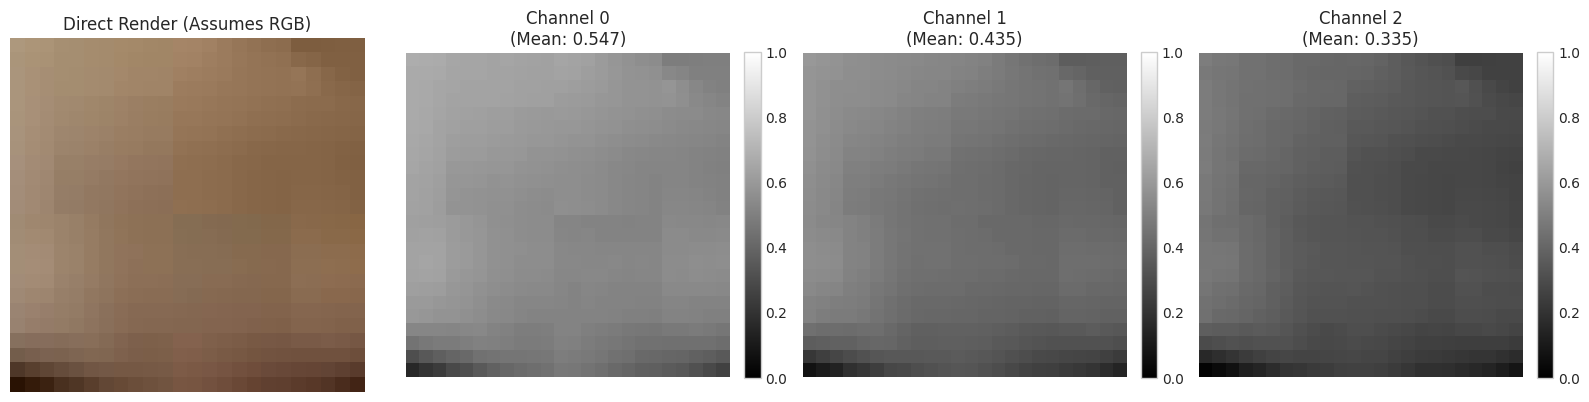

Starting optimization loop...
Epoch 01/75 | LR: 0.000084 | Train Loss: 1.3089 | Val Loss: 1.3000
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 1.3000)
Epoch 02/75 | LR: 0.000138 | Train Loss: 1.2978 | Val Loss: 1.2947
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 1.2947)
Epoch 03/75 | LR: 0.000192 | Train Loss: 1.2941 | Val Loss: 1.2922
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 1.2922)
Epoch 04/75 | LR: 0.000246 | Train Loss: 1.2928 | Val Loss: 1.2906
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 1.2906)


/home/cristic/anaconda3/envs/rppg/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 05/75 | LR: 0.000300 | Train Loss: 1.2917 | Val Loss: 1.2896
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 1.2896)
Epoch 06/75 | LR: 0.000300 | Train Loss: 1.2911 | Val Loss: 1.2895
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 1.2895)
Epoch 07/75 | LR: 0.000299 | Train Loss: 1.2898 | Val Loss: 1.2866
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 1.2866)
Epoch 08/75 | LR: 0.000299 | Train Loss: 1.2880 | Val Loss: 1.2863
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 1.2863)
Epoch 09/75 | LR: 0.000298 | Train Loss: 1.2875 | Val Loss: 1.2868
   ---> No improvement in validation loss for 1/15 epochs.
Epoch 10/75 | LR: 0.000296 | Train Loss: 1.2870 | Val Loss: 1.2860
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 1.2860)
Epoch 11/75 | 

In [2]:
import os
import json
import math
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch
import random
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

# Configure high-quality visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# Setup default configurations
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
# Force usage of the second GPU (index 1)
gpu_id = 1 
DEVICE = torch.device(f'cuda:{gpu_id}' if torch.cuda.is_available() else 'cpu')
MODEL_SAVE_PATH = Path("spatiotemporal_physnet_best_shuffle.pth")

# Clean existing cache files before starting run
for cache in CACHE_FILES:
    if os.path.exists(cache):
        try:
            os.remove(cache)
            print(f"Removed old cache: {cache}")
        except Exception as e:
            print(f"Error removing cache {cache}: {e}")

# Strict order representing the 9 sub-ROIs + full face boundary configurations
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    """
    Diagnose NPZ color-space representations and plot channel intensities.
    Ensures RGB channels align with spatial tracking configurations.
    """
    print(f"\nEvaluating color space for path: {npz_path}")
    if not os.path.exists(npz_path):
        print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
        return

    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            if not available:
                print("No ROIs found in file keys.")
                return
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key]
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    first_frame = roi_data[0].copy()
    
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

def load_npz_file(file_path):
    """Securely load and parse an NPZ file."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """Analyze and print the metadata keys and array dimensions of loaded files."""
    if data is None:
        print("NPZ Analysis Error: Provided data object is None.")
        return
    print("\n" + "=" * 75)
    print("               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
    print("=" * 75)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
        else:
            print(f"  {key:<27} : Metadata / Scalar Object")
    print("=" * 75 + "\n")

def create_synthetic_dataset(target_dir, num_files=6, num_frames=450):
    """Generate mock datasets matching strict multi-ROI formatting standards."""
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
    print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
    fs = 30.0
    t = np.arange(num_frames) / fs
    
    for i in range(num_files):
        hr_hz = np.random.uniform(1.0, 1.5)
        bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
        bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
        bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
        data_dict = {
            'time_deltas': (t * 1000.0).astype(np.float64),
            'ppg_values': bvp.astype(np.float64)
        }
        
        for roi in ROI_ORDER:
            base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
            pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
            pulse_modulator = np.zeros((num_frames, 24, 24, 3))
            pulse_modulator[..., 0] = bvp[:, None, None] * 0.15
            pulse_modulator[..., 1] = bvp[:, None, None] * 0.55
            pulse_modulator[..., 2] = bvp[:, None, None] * 0.05
            
            roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
            data_dict[roi] = roi_frames
            
        np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
    print("Synthetic dataset successfully created!\n")

class PPGMultiROIDataset(Dataset):
    """Optimized Dataset class with inline spatial and temporal sequence augmentations."""
    def __init__(self, file_paths, sequence_length=450, fs=30.0, augment=False):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.fs = fs
        self.augment = augment
        self.samples = []
        
        self._prepare_samples()

    def _prepare_samples(self):
        """Pre-segment matching timelines into sequence lengths."""
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None:
                continue
            
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            num_windows = length // self.sequence_length
            
            for w in range(num_windows):
                start_idx = w * self.sequence_length
                end_idx = start_idx + self.sequence_length
                self.samples.append((path, start_idx, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start, end = self.samples[idx]
        data = load_npz_file(file_path)
        
        ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
        ppg_segment = data[ppg_key][start:end]
        ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
        ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            
            if actual_key is not None:
                roi_data = data[actual_key][start:end]
            else:
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
            roi_data = roi_data.astype(np.float32) / 255.0
            roi_inputs.append(roi_data)
            
        # Perform coordinated sequence augmentations across all 10 regions
        if self.augment:
            # 50% chance of random horizontal flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=2) for roi in roi_inputs]
                
            # 50% chance of random vertical flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=1) for roi in roi_inputs]
                
            # 50% chance of brightness jittering
            if np.random.rand() > 0.5:
                brightness_factor = np.random.uniform(0.9, 1.1)
                roi_inputs = [np.clip(roi * brightness_factor, 0.0, 1.0) for roi in roi_inputs]
                
        # Structure dimension mapping: (10, T, H, W, C) -> (10, C, T, H, W) -> (10 * C, T, H, W)
        stacked_rois = np.stack(roi_inputs, axis=0)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
        stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))
        
        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

class SpatioTemporalPhysNet(nn.Module):
    """
    Spatio-Temporal convolutional network engineered to extract micro-color variations
    harmoniously across 10 face zones (30 raw input channels).
    """
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))
        )
        
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

class NegativePearsonCorrelationLoss(nn.Module):
    """Loss module measuring BVP signal phase synchronization."""
    def __init__(self):
        super(NegativePearsonCorrelationLoss, self).__init__()

    def forward(self, pred, target):
        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_centered = pred - pred_mean
        target_centered = target - target_mean
        
        r_num = torch.sum(pred_centered * target_centered, dim=-1)
        r_den = torch.sqrt(torch.sum(pred_centered ** 2, dim=-1) * torch.sum(target_centered ** 2, dim=-1) + 1e-8)
        
        pearson_coeff = r_num / r_den
        return 1.0 - torch.mean(pearson_coeff)

def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

def save_model_checkpoint(model, optimizer, epoch, metrics, save_path=MODEL_SAVE_PATH):
    """Save model checkpoint along with optimizer state and validation metrics."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics
    }
    torch.save(checkpoint, save_path)
    print(f"Model checkpoint successfully saved to: {save_path}")

# def load_model_checkpoint(save_path, model, optimizer=None):
#     """Load model weights and optional optimizer states from a checkpoint."""
#     if not os.path.exists(save_path):
#         print(f"Checkpoint path {save_path} does not exist.")
#         return None
#     checkpoint = torch.load(save_path, map_location=DEVICE)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     if optimizer is not None and 'optimizer_state_dict' in checkpoint:
#         optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     print(f"Loaded model checkpoint from: {save_path} (Epoch {checkpoint.get('epoch', 'N/A')})")
#     return checkpoint

if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
    create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=6)

npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
print(f"Total files available for analysis: {len(npz_files)}")

first_file_data = load_npz_file(npz_files[0])
analyze_npz_structure(first_file_data)
inspect_npz_color_space(npz_files[0])
###shuffle files
random.seed(42)
shuffled_files = npz_files.copy()
random.shuffle(shuffled_files)

# Perform split on the shuffled list
split_idx = int(len(shuffled_files) * 0.75)
train_split = shuffled_files[:split_idx]
val_split = shuffled_files[split_idx:]

# train_split = npz_files[:int(len(npz_files) * 0.75)]
# val_split = npz_files[int(len(npz_files) * 0.75):]

train_dataset = PPGMultiROIDataset(train_split, augment=True)
val_dataset = PPGMultiROIDataset(val_split, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,prefetch_factor=4,num_workers=8, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,prefetch_factor=4,num_workers=8, pin_memory=True, persistent_workers=True)

# model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
# criterion_pearson = NegativePearsonCorrelationLoss()
# criterion_mse = nn.MSELoss()
# # optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
# # scheduler = CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)


# num_epochs = 75
# warmup_epochs = 5
# train_losses, val_losses = [], []
# # scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
# scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
# scheduler2 = CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs, eta_min=1e-6)
# scheduler = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[warmup_epochs])
# print("Starting optimization loop...")

# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0
#     for inputs, targets in train_loader:
#         inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
#         optimizer.zero_grad()
#         outputs = model(inputs)
        
#         loss = criterion_pearson(outputs, targets) + 0.3 * criterion_mse(outputs, targets)
#         loss.backward()
#         optimizer.step()
        
#         running_loss += loss.item() * inputs.size(0)
        
#     train_loss = running_loss / len(train_loader.dataset)
#     train_losses.append(train_loss)
    
#     model.eval()
#     running_val_loss = 0.0
#     with torch.no_grad():
#         for val_inputs, val_targets in val_loader:
#             val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
#             val_outputs = model(val_inputs)
#             val_loss = criterion_pearson(val_outputs, val_targets) + 0.3 * criterion_mse(val_outputs, val_targets)
#             running_val_loss += val_loss.item() * val_inputs.size(0)
            
#     val_loss = running_val_loss / len(val_loader.dataset)
#     val_losses.append(val_loss)
    
#     print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# model.eval()
# all_preds, all_trues = [], []

# with torch.no_grad():
#     for val_inputs, val_targets in val_loader:
#         val_inputs = val_inputs.to(DEVICE)
#         preds = model(val_inputs).cpu().numpy()
#         all_preds.extend(preds)
#         all_trues.extend(val_targets.numpy())

# all_preds, all_trues = np.array(all_preds), np.array(all_trues)
# metrics = calculate_metrics(all_preds, all_trues)

# print("\n" + "=" * 50)
# print("              VAL METRICS EVALUATION")
# print("=" * 50)
# print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
# print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
# print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
# print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
# print("=" * 50 + "\n")

# # Save model and demonstrate loading functionality
# ----------------------------------------------------------------------------
# 1. Setup Model, Loss, Optimizer & Scheduler
# ----------------------------------------------------------------------------
model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
criterion_pearson = NegativePearsonCorrelationLoss()
criterion_mse = nn.MSELoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

num_epochs = 75
warmup_epochs = 5

scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
scheduler2 = CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[warmup_epochs])

# ----------------------------------------------------------------------------
# 2. Checkpointing & Early Stopping Settings
# ----------------------------------------------------------------------------
CHECKPOINT_SAVE_PATH = "best_spatiotemporal_physnet.pt"
patience = 15              # Stop after 15 consecutive epochs without improvement
patience_counter = 0
best_val_loss = float('inf')
best_model_weights = None

train_losses, val_losses = [], []

print("Starting optimization loop...")

# ----------------------------------------------------------------------------
# 3. Training & Validation Loop
# ----------------------------------------------------------------------------
for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion_pearson(outputs, targets) + 0.3 * criterion_mse(outputs, targets)
        loss.backward()
        
        # Clip gradients to prevent stability issues in spatio-temporal convolutions
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
            val_outputs = model(val_inputs)
            
            val_loss = criterion_pearson(val_outputs, val_targets) + 0.3 * criterion_mse(val_outputs, val_targets)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
    val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    # --- Update Scheduler ---
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # --- Best Model Checkpointing & Early Stopping Logic ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # best_model_weights = copy.deepcopy(model.state_dict())
        best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        # Save best model to disk
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, CHECKPOINT_SAVE_PATH)
        print(f"   ---> Improved! Saved new best model checkpoint to '{CHECKPOINT_SAVE_PATH}' (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"   ---> No improvement in validation loss for {patience_counter}/{patience} epochs.")
        if patience_counter >= patience:
            print(f"\n[Early Stopping Triggered] Stopping training early at Epoch {epoch+1}.")
            break

# ----------------------------------------------------------------------------
# 4. Load Best Model Weights for Evaluation
# ----------------------------------------------------------------------------
if best_model_weights is not None:
    print(f"\nLoading best model state dict from memory (Best Val Loss: {best_val_loss:.4f})...")
    model.load_state_dict(best_model_weights)

# ----------------------------------------------------------------------------
# 5. Validation Metrics Evaluation
# ----------------------------------------------------------------------------
model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for val_inputs, val_targets in val_loader:
        val_inputs = val_inputs.to(DEVICE)
        preds = model(val_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(val_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("              VAL METRICS EVALUATION")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")

# Demonstration: How to reload from disk in a future session
print(f"Demonstration: Checkpoint stored at '{os.path.abspath(CHECKPOINT_SAVE_PATH)}'")


In [17]:
def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

In [3]:
model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for val_inputs, val_targets in val_loader:
        val_inputs = val_inputs.to(DEVICE)
        preds = model(val_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(val_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("              VAL METRICS EVALUATION")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")


              VAL METRICS EVALUATION
  Pearson Correlation Coefficient (PCC) : 0.0322
  Mean Absolute Error (MAE)            : 17.03 BPM
  Root Mean Squared Error (RMSE)       : 25.07 BPM
  Signal-to-Noise Ratio (SNR)          : -3.89 dB



In [4]:
MODEL_SAVE_PATH = Path("spatiotemporal_long_window450_physnet_best2.pth")
def load_model_checkpoint(save_path, model, optimizer=None):
    if not os.path.exists(save_path):
        print(f"Checkpoint path {save_path} does not exist.")
        return None
        
    # Pass weights_only=False to allow loading custom dicts (metrics, scalar types)
    checkpoint = torch.load(save_path, map_location=DEVICE, weights_only=False)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"Loaded model checkpoint from: {save_path} (Epoch {checkpoint.get('epoch', 'N/A')})")
    return checkpoint
save_model_checkpoint(model, optimizer, num_epochs, metrics, MODEL_SAVE_PATH)
trained_model = load_model_checkpoint(MODEL_SAVE_PATH, model, optimizer)

Model checkpoint successfully saved to: spatiotemporal_long_window450_physnet_best2.pth
Loaded model checkpoint from: spatiotemporal_long_window450_physnet_best2.pth (Epoch 75)


--- INFERENCE RUN ON: 3385_FullHDwebcam_after_chunk12.npz ---
  Predicted HR : 88.00 BPM
  Ground-Truth : 76.00 BPM
  Absolute Error: 12.00 BPM
----------------------------------------------------



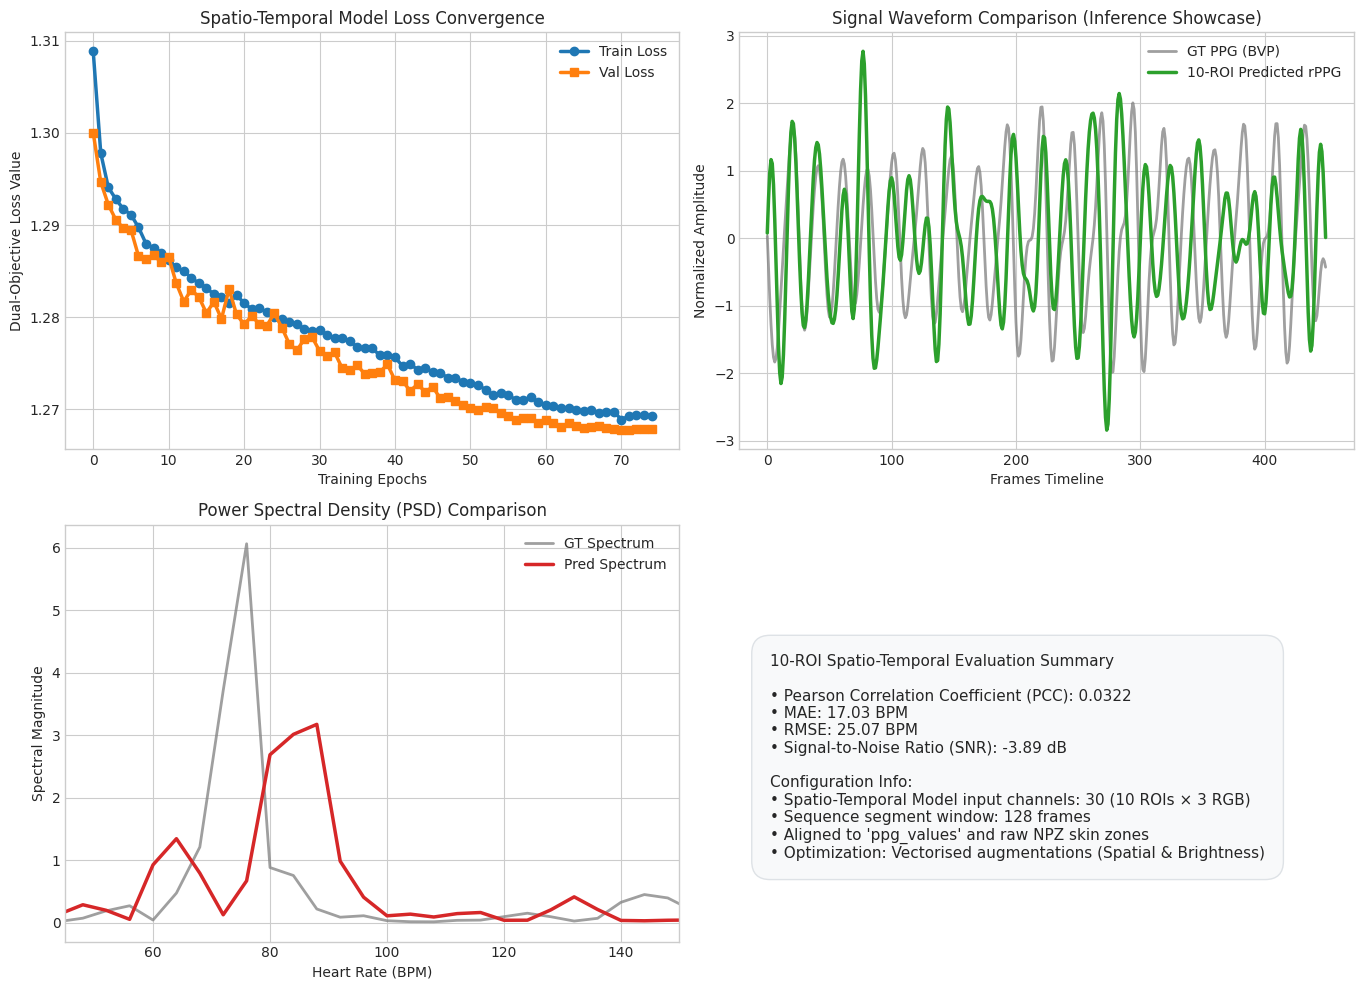

In [11]:

def run_inference_on_sample(npz_file_path, trained_model, sequence_length=450, fs=30.0):
    """Execute inference on a single NPZ validation sample sequence."""
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than the sequence length.")
        return None
        
    target_ppg = data[ppg_key][:sequence_length]
    target_ppg = butter_bandpass_filter(target_ppg, fs=fs)
    target_norm = (target_ppg - np.mean(target_ppg)) / (np.std(target_ppg) + 1e-8)
    
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    trained_model.eval()
    with torch.no_grad():
        output_signal = trained_model(input_tensor).cpu().numpy()[0]
        
    filtered_pred = butter_bandpass_filter(output_signal, fs=fs)
    filtered_pred = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
    hr_pred = calculate_bpm_from_fft(filtered_pred, fs=fs)
    hr_true = calculate_bpm_from_fft(target_norm, fs=fs)
    
    print(f"  Predicted HR : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return filtered_pred, target_norm

sample_val_file = val_split[1]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
axs[0, 0].plot(val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s')
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Dual-Objective Loss Value')
axs[0, 0].legend()

if inference_pred is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (BVP)', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.5)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude')
    axs[0, 1].legend()

if inference_pred is not None:
    pred_det = inference_pred - np.mean(inference_pred)
    true_det = inference_gt - np.mean(inference_gt)
    
    freqs_p, psd_p = welch(pred_det, fs=30.0, nperseg=len(pred_det))
    freqs_t, psd_t = welch(true_det, fs=30.0, nperseg=len(true_det))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.5)
    axs[1, 0].set_xlim(45, 150)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model input channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 128 frames\n"
    f"• Aligned to 'ppg_values' and raw NPZ skin zones\n"
    f"• Optimization: Vectorised augmentations (Spatial & Brightness)"
)
axs[1, 1].text(0.05, 0.2, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

W0000 00:00:1784871478.100184 1738736 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1784871478.740774 1738736 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1784871478.792232 1739047 gl_context.cc:343] failed to get GL_VERSION string
I0000 00:00:1784871478.792281 1739047 gl_context.cc:385] GL version: 3.2 (), renderer: (null)
E0000 00:00:1784871478.792308 1739047 gl_context.cc:310] Error querying for GL extensions
I0000 00:00:1784871478.792593 1738736 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1784871478.795459 1739048 gl_context.cc:343] failed to get GL_VERSION string
I0000 00:00:1784871478.795501 1739048 gl_context.cc:385] GL version: 3.2 (), renderer: (null)
E0000 00:00:1784871478.795523 1739048 gl_context.cc:310] Error querying for GL extensions
I0000 00:00:1784871478.795727 1738736 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor:

Successfully loaded model weights from: spatiotemporal_physnet_best.pth
Loaded 450 frames from '9998_USBVideo_after.avi' @ 30.00 FPS

Model Input Tensor Shape : torch.Size([1, 30, 450, 24, 24])
Target Hardware Execution : cuda:1


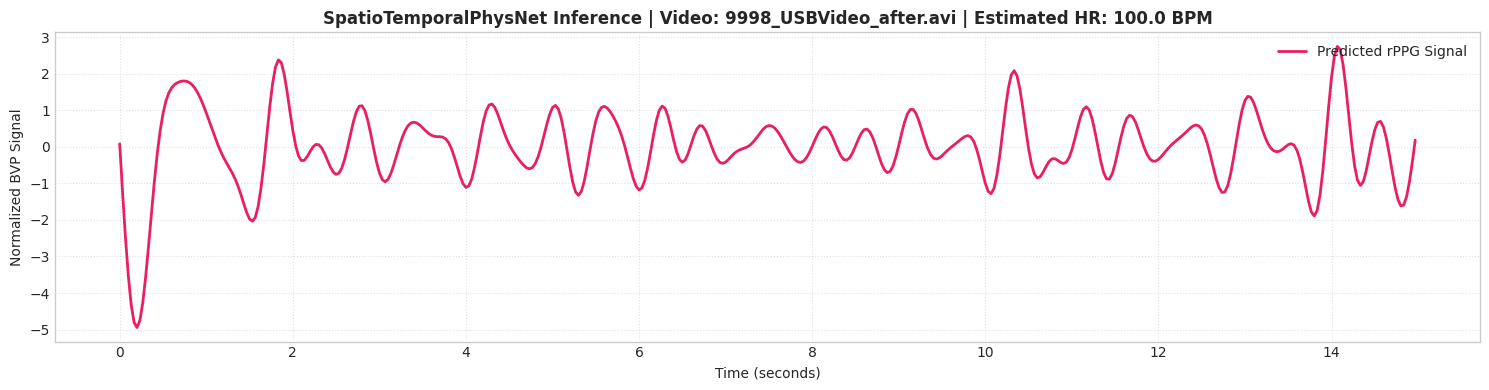

In [9]:
# ============================================================================
# Standalone Inference Cell: Video (.avi) -> MediaPipe 10-ROI -> PhysNet Model
# ============================================================================
import os
import cv2
import math
import imageio
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ----------------------------------------------------------------------------
# 1. Configuration & Constants
# ----------------------------------------------------------------------------
VIDEO_PATH = '/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/video/9998_USBVideo_after.avi'  # Path to your target .avi video
MEDIAPIPE_MODEL_PATH = '/home/cristic/face_landmarker.task'
MODEL_CHECKPOINT_PATH = 'spatiotemporal_physnet_best.pth'

CHUNK_SIZE = 450
ROI_BOX_SIZE = (24, 24)
DEVICE = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# Exact 10 ROI ordering expected by SpatioTemporalPhysNet (30 input channels)
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

# MediaPipe landmark mappings for the 10 ROIs
ROIS_MAPPING = {
    'roi_full_face': list(range(468)),
    'roi_forehead': [10, 67, 69, 108, 109, 151, 337, 338, 297, 299, 9, 8],
    'roi_left_eye': [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246],
    'roi_right_eye': [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398],
    'roi_nose': [1, 2, 98, 327, 328, 2, 4, 5, 195, 197, 6, 168],
    'roi_mouth': [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 95],
    'roi_chin': [152, 148, 176, 149, 150, 136, 172, 377, 400, 378, 379, 365, 397],
    'roi_right_cheek_50': [50],
    'roi_left_cheek_280': [280],
    'roi_chin_199': [199]
}

# ----------------------------------------------------------------------------
# 2. MediaPipe Detector & ROI Helper Definitions
# ----------------------------------------------------------------------------
class ModernFaceMeshDetector:
    def __init__(self, model_path):
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.VIDEO,
            num_faces=1,
            min_face_detection_confidence=0.5,
            min_face_presence_confidence=0.5,
            min_tracking_confidence=0.5
        )
        self.landmarker = vision.FaceLandmarker.create_from_options(options)
        self.timestamp_ms = 0

    def detect_landmarks(self, frame_rgb):
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        self.timestamp_ms += 33  # ~30 FPS step
        detection_result = self.landmarker.detect_for_video(mp_image, self.timestamp_ms)
        
        if detection_result.face_landmarks:
            h, w = frame_rgb.shape[:2]
            landmarks = detection_result.face_landmarks[0]
            # Convert normalized coordinates to pixel coordinates
            return np.array([[lm.x * w, lm.y * h] for lm in landmarks], dtype=np.float32)
        return None

    def reset(self):
        self.timestamp_ms = 0

    def close(self):
        self.landmarker.close()


def extract_roi_bbox(landmarks, indices, frame_shape, target_size=(24, 24)):
    h, w = frame_shape
    roi_lms = landmarks[indices]
    
    if len(indices) == 1:
        # Point landmark (e.g., cheek, chin point) -> center crop around landmark
        cx, cy = roi_lms[0]
        crop_w, crop_h = target_size
        x = int(cx - crop_w / 2)
        y = int(cy - crop_h / 2)
    else:
        # Multi-point ROI -> calculate bounding box
        min_x, min_y = np.min(roi_lms, axis=0)
        max_x, max_y = np.max(roi_lms, axis=0)
        x, y = int(min_x), int(min_y)
        crop_w, crop_h = int(max_x - min_x), int(max_y - min_y)
        
    x = max(0, min(x, w - 1))
    y = max(0, min(y, h - 1))
    crop_w = max(1, min(crop_w, w - x))
    crop_h = max(1, min(crop_h, h - y))
    
    return (x, y, crop_w, crop_h)


def extract_roi_region(frame, bbox, target_size=ROI_BOX_SIZE):
    x, y, w, h = bbox
    crop = frame[y:y+h, x:x+w]
    if crop.size == 0:
        return np.zeros((*target_size, 3), dtype=np.uint8)
    return cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)

# ----------------------------------------------------------------------------
# 3. Signal Processing Helper Functions
# ----------------------------------------------------------------------------
def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

# ----------------------------------------------------------------------------
# 4. Model Architecture Load
# ----------------------------------------------------------------------------
class SpatioTemporalPhysNet(nn.Module):
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))
        )
        
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

# ----------------------------------------------------------------------------
# 5. Video Processing Pipeline
# ----------------------------------------------------------------------------
def process_video_for_physnet(video_path, detector, chunk_size=CHUNK_SIZE):
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found at: {video_path}")
        
    reader = imageio.get_reader(video_path, 'ffmpeg')
    meta = reader.get_meta_data()
    fps = meta.get('fps', 30.0)
    
    frames = []
    for i, frame in enumerate(reader):
        if i >= chunk_size:
            break
        frames.append(frame)
    reader.close()
    
    num_frames = len(frames)
    print(f"Loaded {num_frames} frames from '{os.path.basename(video_path)}' @ {fps:.2f} FPS")
    
    # Pad short videos if needed
    if num_frames < chunk_size:
        pad_count = chunk_size - num_frames
        frames += [frames[-1]] * pad_count
        print(f"Padded video from {num_frames} to {chunk_size} frames.")
        
    # Extract landmarks per frame
    chunk_landmarks = []
    detector.reset()
    for frame in frames:
        lms = detector.detect_landmarks(frame)
        if lms is not None:
            chunk_landmarks.append(lms)
        elif chunk_landmarks:
            chunk_landmarks.append(chunk_landmarks[-1].copy())
        else:
            chunk_landmarks.append(np.zeros((468, 2), dtype='float32'))
            
    chunk_landmarks = np.array(chunk_landmarks)
    
    # Crop ROIs for all frames
    roi_inputs = []
    for roi_name in ROI_ORDER:
        roi_indices = ROIS_MAPPING[roi_name]
        roi_frames = []
        for frame_idx, frame in enumerate(frames):
            landmarks = chunk_landmarks[frame_idx]
            if np.all(landmarks == 0):
                h, w = frame.shape[:2]
                bbox = (w // 2 - ROI_BOX_SIZE[0] // 2, h // 2 - ROI_BOX_SIZE[1] // 2, ROI_BOX_SIZE[0], ROI_BOX_SIZE[1])
            else:
                bbox = extract_roi_bbox(landmarks, roi_indices, frame.shape[:2], ROI_BOX_SIZE)
            
            roi_region = extract_roi_region(frame, bbox)
            roi_frames.append(roi_region)
            
        roi_array = np.array(roi_frames, dtype=np.float32) / 255.0  # (T, 24, 24, 3)
        roi_inputs.append(roi_array)
        
    # Format shape to match model input: (10, T, H, W, C) -> (1, 30, T, 24, 24)
    stacked_rois = np.stack(roi_inputs, axis=0)                     # (10, 450, 24, 24, 3)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))     # (10, 3, 450, 24, 24)
    stacked_rois = np.reshape(stacked_rois, (10 * 3, CHUNK_SIZE, 24, 24)) # (30, 450, 24, 24)
    
    tensor_input = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0) # (1, 30, 450, 24, 24)
    return tensor_input, fps

# ----------------------------------------------------------------------------
# 6. Pipeline Execution
# ----------------------------------------------------------------------------
# Initialize MediaPipe Detector
detector = ModernFaceMeshDetector(model_path=MEDIAPIPE_MODEL_PATH)

# Initialize Model & Load Weights
model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
if os.path.exists(MODEL_CHECKPOINT_PATH):
    # checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=DEVICE)
    checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    print(f"Successfully loaded model weights from: {MODEL_CHECKPOINT_PATH}")
else:
    print(f"[Warning] Checkpoint '{MODEL_CHECKPOINT_PATH}' not found. Using randomly initialized model.")

model.eval()

# Process video and perform forward pass
input_tensor, video_fps = process_video_for_physnet(VIDEO_PATH, detector, chunk_size=CHUNK_SIZE)
input_tensor = input_tensor.to(DEVICE)

print(f"\nModel Input Tensor Shape : {input_tensor.shape}")
print(f"Target Hardware Execution : {DEVICE}")

with torch.no_grad():
    predicted_ppg = model(input_tensor).squeeze(0).cpu().numpy()

# Post-processing & HR Extraction
filtered_ppg = butter_bandpass_filter(predicted_ppg, fs=video_fps)
normalized_ppg = (filtered_ppg - np.mean(filtered_ppg)) / (np.std(filtered_ppg) + 1e-8)
estimated_bpm = calculate_bpm_from_fft(filtered_ppg, fs=video_fps)

# Render Waveform Visualization
timeline = np.arange(len(normalized_ppg)) / video_fps
plt.figure(figsize=(15, 4))
plt.plot(timeline, normalized_ppg, color='#e91e63', linewidth=2, label='Predicted rPPG Signal')
plt.title(f"SpatioTemporalPhysNet Inference | Video: {os.path.basename(VIDEO_PATH)} | Estimated HR: {estimated_bpm:.1f} BPM", fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized BVP Signal")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Clean up detector
detector.close()

In [11]:
import pandas as pd

CSV_PATH = "/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/db.csv"

# Load header only for instant inspection
df = pd.read_csv(CSV_PATH, nrows=5)

print(f"Total Columns ({len(df.columns)}):")
print(df.columns.tolist())

Total Columns (25):
['patient_id', 'weight', 'height', 'bmi', 'age', 'sex', 'upper_ap', 'lower_ap', 'saturation', 'temperature', 'hemoglobin', 'glycated_hemoglobin', 'cholesterol', 'respiratory', 'rigidity', 'pulse', 'stress', 'step', 'camera', 'view', 'ecg', 'ppg', 'video', 'meta', 'ppg_sync']


In [12]:
import pandas as pd

CSV_PATH = "/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/db.csv"
df = pd.read_csv(CSV_PATH)

# Support flexible column naming depending on exact header case/alias
patient_col = 'patient_id' if 'patient_id' in df.columns else 'patient'

# Filter by subject 9998 and USBVideo camera
filtered_df = df[
    (df[patient_col].astype(str).str.contains('9998')) & 
    (df['camera'].astype(str).str.contains('USBVideo', case=False, na=False))
]

# Display relevant identification columns alongside pulse
display_cols = [col for col in [patient_col, 'step', 'camera', 'view', 'pulse'] if col in df.columns]
print(filtered_df[display_cols])

      patient_id    step    camera  view  pulse
3595        9998   after  USBVideo  left  117.0
3598        9998  before  USBVideo  left  100.0


Loaded 450 frames from '1091_USBVideo_before.avi' @ 30.00 FPS

Model Input Tensor Shape : torch.Size([1, 30, 450, 24, 24])
Target Hardware Execution : cuda:1


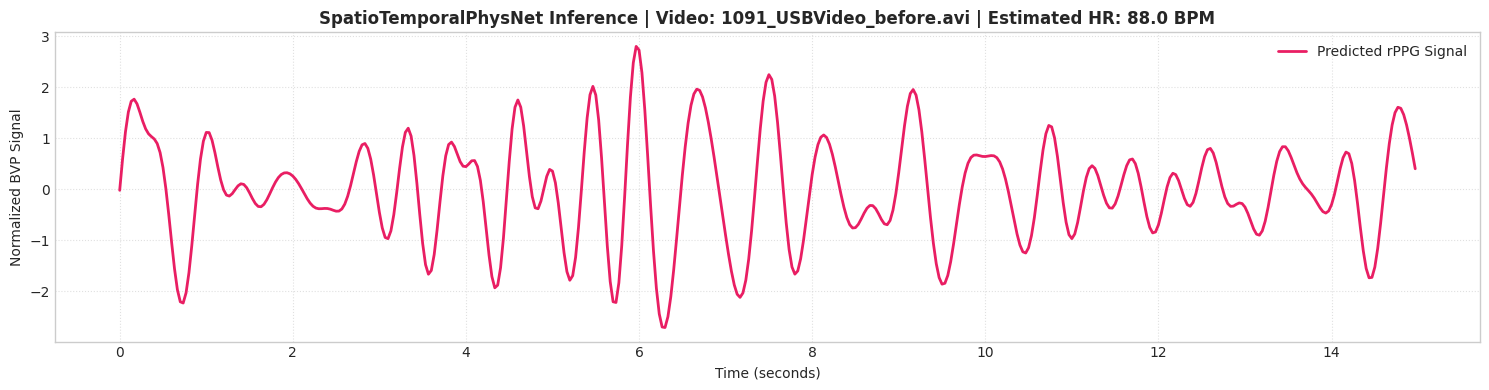

In [13]:
# Process video and perform forward pass
VIDEO_PATH = '/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/video/1091_USBVideo_before.avi' 
input_tensor, video_fps = process_video_for_physnet(VIDEO_PATH, detector, chunk_size=CHUNK_SIZE)
input_tensor = input_tensor.to(DEVICE)

print(f"\nModel Input Tensor Shape : {input_tensor.shape}")
print(f"Target Hardware Execution : {DEVICE}")

with torch.no_grad():
    predicted_ppg = model(input_tensor).squeeze(0).cpu().numpy()

# Post-processing & HR Extraction
filtered_ppg = butter_bandpass_filter(predicted_ppg, fs=video_fps)
normalized_ppg = (filtered_ppg - np.mean(filtered_ppg)) / (np.std(filtered_ppg) + 1e-8)
estimated_bpm = calculate_bpm_from_fft(filtered_ppg, fs=video_fps)

# Render Waveform Visualization
timeline = np.arange(len(normalized_ppg)) / video_fps
plt.figure(figsize=(15, 4))
plt.plot(timeline, normalized_ppg, color='#e91e63', linewidth=2, label='Predicted rPPG Signal')
plt.title(f"SpatioTemporalPhysNet Inference | Video: {os.path.basename(VIDEO_PATH)} | Estimated HR: {estimated_bpm:.1f} BPM", fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized BVP Signal")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Clean up detector
detector.close()

In [14]:
# Filter by subject 9998 and USBVideo camera
filtered_df = df[
    (df[patient_col].astype(str).str.contains('1091')) & 
    (df['camera'].astype(str).str.contains('USBVideo', case=False, na=False))
]

# Display relevant identification columns alongside pulse
display_cols = [col for col in [patient_col, 'step', 'camera', 'view', 'pulse'] if col in df.columns]
print(filtered_df[display_cols])

    patient_id    step    camera  view  pulse
19        1091   after  USBVideo  left  132.0
22        1091  before  USBVideo  left   94.0


W0000 00:00:1784828864.871238  384288 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1784828864.901005  384288 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1784828864.919883  384347 gl_context.cc:343] failed to get GL_VERSION string
I0000 00:00:1784828864.920044  384347 gl_context.cc:385] GL version: 3.2 (), renderer: (null)
E0000 00:00:1784828864.920104  384347 gl_context.cc:310] Error querying for GL extensions
I0000 00:00:1784828864.920818  384288 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1784828864.928227  384348 gl_context.cc:343] failed to get GL_VERSION string
I0000 00:00:1784828864.928252  384348 gl_context.cc:385] GL version: 3.2 (), renderer: (null)
E0000 00:00:1784828864.928272  384348 gl_context.cc:310] Error querying for GL extensions
I0000 00:00:1784828864.929400  384288 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor:

Successfully loaded model weights from: spatiotemporal_long_window450_physnet_best2.pth
Loaded 450 frames from '9998_USBVideo_after.avi' @ 30.00 FPS

Model Input Tensor Shape : torch.Size([1, 30, 450, 24, 24])
Target Hardware Execution : cuda:1


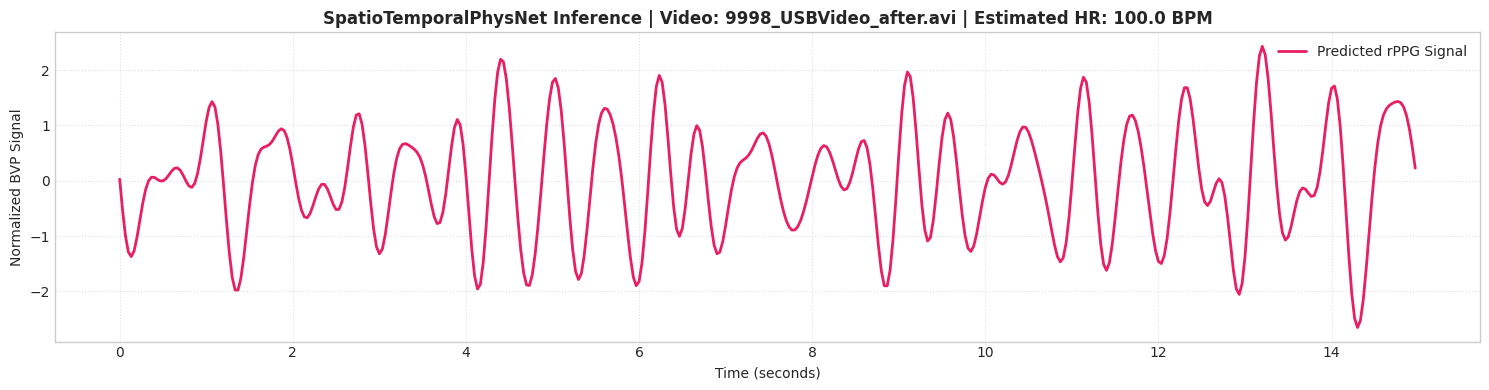

In [20]:
# ============================================================================
# Standalone Inference Cell: Video (.avi) -> MediaPipe 10-ROI -> PhysNet Model
# ============================================================================
import os
import cv2
import math
import imageio
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ----------------------------------------------------------------------------
# 1. Configuration & Constants
# ----------------------------------------------------------------------------
VIDEO_PATH = '/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/video/9998_USBVideo_after.avi'  # Path to your target .avi video
MEDIAPIPE_MODEL_PATH = '/home/cristic/face_landmarker.task'
MODEL_CHECKPOINT_PATH = 'spatiotemporal_long_window450_physnet_best2.pth'

CHUNK_SIZE = 450
ROI_BOX_SIZE = (24, 24)
DEVICE = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# Exact 10 ROI ordering expected by SpatioTemporalPhysNet (30 input channels)
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

# MediaPipe landmark mappings for the 10 ROIs
ROIS_MAPPING = {
    'roi_full_face': list(range(468)),
    'roi_forehead': [10, 67, 69, 108, 109, 151, 337, 338, 297, 299, 9, 8],
    'roi_left_eye': [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246],
    'roi_right_eye': [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398],
    'roi_nose': [1, 2, 98, 327, 328, 2, 4, 5, 195, 197, 6, 168],
    'roi_mouth': [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 95],
    'roi_chin': [152, 148, 176, 149, 150, 136, 172, 377, 400, 378, 379, 365, 397],
    'roi_right_cheek_50': [50],
    'roi_left_cheek_280': [280],
    'roi_chin_199': [199]
}

# ----------------------------------------------------------------------------
# 2. MediaPipe Detector & ROI Helper Definitions
# ----------------------------------------------------------------------------
class ModernFaceMeshDetector:
    def __init__(self, model_path):
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.VIDEO,
            num_faces=1,
            min_face_detection_confidence=0.5,
            min_face_presence_confidence=0.5,
            min_tracking_confidence=0.5
        )
        self.landmarker = vision.FaceLandmarker.create_from_options(options)
        self.timestamp_ms = 0

    def detect_landmarks(self, frame_rgb):
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        self.timestamp_ms += 33  # ~30 FPS step
        detection_result = self.landmarker.detect_for_video(mp_image, self.timestamp_ms)
        
        if detection_result.face_landmarks:
            h, w = frame_rgb.shape[:2]
            landmarks = detection_result.face_landmarks[0]
            # Convert normalized coordinates to pixel coordinates
            return np.array([[lm.x * w, lm.y * h] for lm in landmarks], dtype=np.float32)
        return None

    def reset(self):
        self.timestamp_ms = 0

    def close(self):
        self.landmarker.close()


def extract_roi_bbox(landmarks, indices, frame_shape, target_size=(24, 24)):
    h, w = frame_shape
    roi_lms = landmarks[indices]
    
    if len(indices) == 1:
        # Point landmark (e.g., cheek, chin point) -> center crop around landmark
        cx, cy = roi_lms[0]
        crop_w, crop_h = target_size
        x = int(cx - crop_w / 2)
        y = int(cy - crop_h / 2)
    else:
        # Multi-point ROI -> calculate bounding box
        min_x, min_y = np.min(roi_lms, axis=0)
        max_x, max_y = np.max(roi_lms, axis=0)
        x, y = int(min_x), int(min_y)
        crop_w, crop_h = int(max_x - min_x), int(max_y - min_y)
        
    x = max(0, min(x, w - 1))
    y = max(0, min(y, h - 1))
    crop_w = max(1, min(crop_w, w - x))
    crop_h = max(1, min(crop_h, h - y))
    
    return (x, y, crop_w, crop_h)


def extract_roi_region(frame, bbox, target_size=ROI_BOX_SIZE):
    x, y, w, h = bbox
    crop = frame[y:y+h, x:x+w]
    if crop.size == 0:
        return np.zeros((*target_size, 3), dtype=np.uint8)
    return cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)

# ----------------------------------------------------------------------------
# 3. Signal Processing Helper Functions
# ----------------------------------------------------------------------------
def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

# ----------------------------------------------------------------------------
# 4. Model Architecture Load
# ----------------------------------------------------------------------------
class SpatioTemporalPhysNet(nn.Module):
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))
        )
        
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

# ----------------------------------------------------------------------------
# 5. Video Processing Pipeline
# ----------------------------------------------------------------------------
def process_video_for_physnet(video_path, detector, chunk_size=CHUNK_SIZE):
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found at: {video_path}")
        
    reader = imageio.get_reader(video_path, 'ffmpeg')
    meta = reader.get_meta_data()
    fps = meta.get('fps', 30.0)
    
    frames = []
    for i, frame in enumerate(reader):
        if i >= chunk_size:
            break
        frames.append(frame)
    reader.close()
    
    num_frames = len(frames)
    print(f"Loaded {num_frames} frames from '{os.path.basename(video_path)}' @ {fps:.2f} FPS")
    
    # Pad short videos if needed
    if num_frames < chunk_size:
        pad_count = chunk_size - num_frames
        frames += [frames[-1]] * pad_count
        print(f"Padded video from {num_frames} to {chunk_size} frames.")
        
    # Extract landmarks per frame
    chunk_landmarks = []
    detector.reset()
    for frame in frames:
        lms = detector.detect_landmarks(frame)
        if lms is not None:
            chunk_landmarks.append(lms)
        elif chunk_landmarks:
            chunk_landmarks.append(chunk_landmarks[-1].copy())
        else:
            chunk_landmarks.append(np.zeros((468, 2), dtype='float32'))
            
    chunk_landmarks = np.array(chunk_landmarks)
    
    # Crop ROIs for all frames
    roi_inputs = []
    for roi_name in ROI_ORDER:
        roi_indices = ROIS_MAPPING[roi_name]
        roi_frames = []
        for frame_idx, frame in enumerate(frames):
            landmarks = chunk_landmarks[frame_idx]
            if np.all(landmarks == 0):
                h, w = frame.shape[:2]
                bbox = (w // 2 - ROI_BOX_SIZE[0] // 2, h // 2 - ROI_BOX_SIZE[1] // 2, ROI_BOX_SIZE[0], ROI_BOX_SIZE[1])
            else:
                bbox = extract_roi_bbox(landmarks, roi_indices, frame.shape[:2], ROI_BOX_SIZE)
            
            roi_region = extract_roi_region(frame, bbox)
            roi_frames.append(roi_region)
            
        roi_array = np.array(roi_frames, dtype=np.float32) / 255.0  # (T, 24, 24, 3)
        roi_inputs.append(roi_array)
        
    # Format shape to match model input: (10, T, H, W, C) -> (1, 30, T, 24, 24)
    stacked_rois = np.stack(roi_inputs, axis=0)                     # (10, 450, 24, 24, 3)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))     # (10, 3, 450, 24, 24)
    stacked_rois = np.reshape(stacked_rois, (10 * 3, CHUNK_SIZE, 24, 24)) # (30, 450, 24, 24)
    
    tensor_input = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0) # (1, 30, 450, 24, 24)
    return tensor_input, fps

# ----------------------------------------------------------------------------
# 6. Pipeline Execution
# ----------------------------------------------------------------------------
# Initialize MediaPipe Detector
detector = ModernFaceMeshDetector(model_path=MEDIAPIPE_MODEL_PATH)

# Initialize Model & Load Weights
model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
if os.path.exists(MODEL_CHECKPOINT_PATH):
    # checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=DEVICE)
    checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    print(f"Successfully loaded model weights from: {MODEL_CHECKPOINT_PATH}")
else:
    print(f"[Warning] Checkpoint '{MODEL_CHECKPOINT_PATH}' not found. Using randomly initialized model.")

model.eval()

# Process video and perform forward pass
input_tensor, video_fps = process_video_for_physnet(VIDEO_PATH, detector, chunk_size=CHUNK_SIZE)
input_tensor = input_tensor.to(DEVICE)

print(f"\nModel Input Tensor Shape : {input_tensor.shape}")
print(f"Target Hardware Execution : {DEVICE}")

with torch.no_grad():
    predicted_ppg = model(input_tensor).squeeze(0).cpu().numpy()

# Post-processing & HR Extraction
filtered_ppg = butter_bandpass_filter(predicted_ppg, fs=video_fps)
normalized_ppg = (filtered_ppg - np.mean(filtered_ppg)) / (np.std(filtered_ppg) + 1e-8)
estimated_bpm = calculate_bpm_from_fft(filtered_ppg, fs=video_fps)

# Render Waveform Visualization
timeline = np.arange(len(normalized_ppg)) / video_fps
plt.figure(figsize=(15, 4))
plt.plot(timeline, normalized_ppg, color='#e91e63', linewidth=2, label='Predicted rPPG Signal')
plt.title(f"SpatioTemporalPhysNet Inference | Video: {os.path.basename(VIDEO_PATH)} | Estimated HR: {estimated_bpm:.1f} BPM", fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized BVP Signal")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Clean up detector
detector.close()

In [ ]:
PSDloss Model

Total files available for analysis: 26322

               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)
  landmarks                   : Shape (450, 468, 2)        | Dtype float32
  meta_camera_type            : Shape ()                   | Dtype <U12
  meta_chunk_index            : Shape ()                   | Dtype int64
  meta_condition              : Shape ()                   | Dtype <U5
  meta_end_frame              : Shape ()                   | Dtype int64
  meta_num_frames             : Shape ()                   | Dtype int64
  meta_start_frame            : Shape ()                   | Dtype int64
  meta_subject_id             : Shape ()                   | Dtype int64
  meta_view_type              : Shape ()                   | Dtype <U5
  ppg_values                  : Shape (450,)               | Dtype float64
  roi_chin                    : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_chin_199                : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_fore

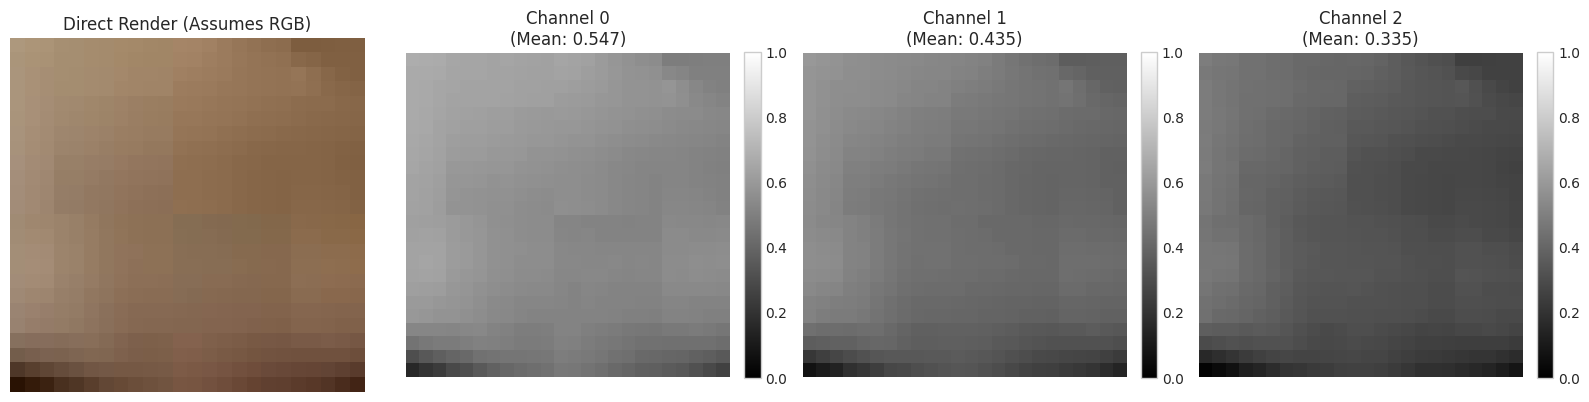

Starting optimization loop...
Epoch 01/150 | LR: 0.000043 | Train Loss: 4.8899 | Val Loss: 4.6437 | Val PCC: -0.0075
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 4.6437)
Epoch 02/150 | LR: 0.000057 | Train Loss: 4.6220 | Val Loss: 4.5884 | Val PCC: -0.0091
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 4.5884)
Epoch 03/150 | LR: 0.000070 | Train Loss: 4.5741 | Val Loss: 4.5553 | Val PCC: -0.0080
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 4.5553)
Epoch 04/150 | LR: 0.000084 | Train Loss: 4.5386 | Val Loss: 4.5331 | Val PCC: -0.0069
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 4.5331)
Epoch 05/150 | LR: 0.000097 | Train Loss: 4.5089 | Val Loss: 4.5138 | Val PCC: -0.0060
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 4.5138)
Epoch 06/1

/home/cristic/anaconda3/envs/rppg/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 20/150 | LR: 0.000300 | Train Loss: 4.2844 | Val Loss: 4.3297 | Val PCC: -0.0026
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 4.3297)
Epoch 21/150 | LR: 0.000300 | Train Loss: 4.2739 | Val Loss: 4.3334 | Val PCC: -0.0029
   ---> No improvement in validation loss for 1/15 epochs.
Epoch 22/150 | LR: 0.000300 | Train Loss: 4.0039 | Val Loss: 4.0189 | Val PCC: -0.0010
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 4.0189)
Epoch 23/150 | LR: 0.000300 | Train Loss: 3.9999 | Val Loss: 4.0177 | Val PCC: -0.0016
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 4.0177)
Epoch 24/150 | LR: 0.000299 | Train Loss: 3.9961 | Val Loss: 4.0140 | Val PCC: -0.0010
   ---> Improved! Saved new best model checkpoint to 'best_spatiotemporal_physnet.pt' (Val Loss: 4.0140)
Epoch 25/150 | LR: 0.000299 | Train Loss: 3.9953 | Val Loss: 4.0213 | Val PCC: -0.0001

In [24]:
import os
import json
import math
import copy
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

# Configure high-quality visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# Setup default configurations
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
# Force usage of the second GPU (index 1)
gpu_id = 1 
DEVICE = torch.device(f'cuda:{gpu_id}' if torch.cuda.is_available() else 'cpu')
MODEL_SAVE_PATH = Path("spatiotemporal_physnet_best_shuffle.pth")

# Clean existing cache files before starting run
for cache in CACHE_FILES:
    if os.path.exists(cache):
        try:
            os.remove(cache)
            print(f"Removed old cache: {cache}")
        except Exception as e:
            print(f"Error removing cache {cache}: {e}")

# Strict order representing the 9 sub-ROIs + full face boundary configurations
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    """
    Diagnose NPZ color-space representations and plot channel intensities.
    Ensures RGB channels align with spatial tracking configurations.
    """
    print(f"\nEvaluating color space for path: {npz_path}")
    if not os.path.exists(npz_path):
        print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
        return

    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            if not available:
                print("No ROIs found in file keys.")
                return
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key]
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    first_frame = roi_data[0].copy()
    
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

def load_npz_file(file_path):
    """Securely load and parse an NPZ file."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """Analyze and print the metadata keys and array dimensions of loaded files."""
    if data is None:
        print("NPZ Analysis Error: Provided data object is None.")
        return
    print("\n" + "=" * 75)
    print("               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
    print("=" * 75)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
        else:
            print(f"  {key:<27} : Metadata / Scalar Object")
    print("=" * 75 + "\n")

def create_synthetic_dataset(target_dir, num_files=12, num_frames=450):
    """Generate mock datasets matching strict multi-ROI formatting standards."""
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
    print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
    fs = 30.0
    t = np.arange(num_frames) / fs
    
    for i in range(num_files):
        hr_hz = np.random.uniform(1.0, 1.5)
        bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
        bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
        bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
        data_dict = {
            'time_deltas': (t * 1000.0).astype(np.float64),
            'ppg_values': bvp.astype(np.float64)
        }
        
        for roi in ROI_ORDER:
            base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
            pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
            pulse_modulator = np.zeros((num_frames, 24, 24, 3))
            pulse_modulator[..., 0] = bvp[:, None, None] * 0.15
            pulse_modulator[..., 1] = bvp[:, None, None] * 0.55
            pulse_modulator[..., 2] = bvp[:, None, None] * 0.05
            
            roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
            data_dict[roi] = roi_frames
            
        np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
    print("Synthetic dataset successfully created!\n")

class PPGMultiROIDataset(Dataset):
    """Optimized Dataset class with inline spatial and temporal sequence augmentations."""
    def __init__(self, file_paths, sequence_length=450, fs=30.0, augment=False):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.fs = fs
        self.augment = augment
        self.samples = []
        
        self._prepare_samples()

    def _prepare_samples(self):
        """Pre-segment matching timelines into sequence lengths."""
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None:
                continue
            
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            num_windows = length // self.sequence_length
            
            for w in range(num_windows):
                start_idx = w * self.sequence_length
                end_idx = start_idx + self.sequence_length
                self.samples.append((path, start_idx, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start, end = self.samples[idx]
        data = load_npz_file(file_path)
        
        ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
        ppg_segment = data[ppg_key][start:end]
        ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
        
        # 2. Standardize Target Waveforms (Zero-mean, unit-variance)
        ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            
            if actual_key is not None:
                roi_data = data[actual_key][start:end]
            else:
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
            roi_data = roi_data.astype(np.float32) / 255.0
            roi_inputs.append(roi_data)
            
        # Perform coordinated sequence augmentations across all 10 regions
        if self.augment:
            # 50% chance of random horizontal flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=2) for roi in roi_inputs]
                
            # 50% chance of random vertical flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=1) for roi in roi_inputs]
                
            # 50% chance of brightness jittering
            if np.random.rand() > 0.5:
                brightness_factor = np.random.uniform(0.9, 1.1)
                roi_inputs = [np.clip(roi * brightness_factor, 0.0, 1.0) for roi in roi_inputs]
                
        # Structure dimension mapping: (10, T, H, W, C) -> (10, C, T, H, W) -> (10 * C, T, H, W)
        stacked_rois = np.stack(roi_inputs, axis=0)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
        stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))
        
        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

class SpatioTemporalPhysNet(nn.Module):
    """
    Spatio-Temporal convolutional network engineered to extract micro-color variations
    harmoniously across 10 face zones (30 raw input channels).
    """
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))
        )
        
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        # 1. Standard Normalization for Input Tensors (Temporal Z-Score Standardization)
        # x shape: (B, C, T, H, W) -> standardize over T per channel
        mean = x.mean(dim=2, keepdim=True)
        # std = x.std(dim=2, keepdim=True) + 1e-8
        # x = (x - mean) / std
        x = (x - mean) / (mean + 1e-8) 
        
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

# class NegativePearsonCorrelationLoss(nn.Module):
#     """Loss module measuring BVP signal phase synchronization."""
#     def __init__(self):
#         super(NegativePearsonCorrelationLoss, self).__init__()

#     def forward(self, pred, target):
#         pred_mean = torch.mean(pred, dim=-1, keepdim=True)
#         target_mean = torch.mean(target, dim=-1, keepdim=True)
        
#         pred_centered = pred - pred_mean
#         target_centered = target - target_mean
        
#         r_num = torch.sum(pred_centered * target_centered, dim=-1)
#         r_den = torch.sqrt(torch.sum(pred_centered ** 2, dim=-1) * torch.sum(target_centered ** 2, dim=-1) + 1e-8)
        
#         pearson_coeff = r_num / r_den
#         return 1.0 - torch.mean(pearson_coeff)

import torch
import torch.nn as nn

# class NegativePearsonCorrelationLoss(nn.Module):
#     """Loss module measuring BVP signal phase synchronization."""
#     def __init__(self, eps=1e-8):
#         super(NegativePearsonCorrelationLoss, self).__init__()
#         self.eps = eps

#     def forward(self, pred, target):
#         # Flatten extra spatial/channel dims if needed, keeping batch (dim 0) and time (dim -1)
#         pred = pred.view(pred.size(0), -1)
#         target = target.view(target.size(0), -1)

#         pred_mean = torch.mean(pred, dim=-1, keepdim=True)
#         target_mean = torch.mean(target, dim=-1, keepdim=True)
        
#         pred_centered = pred - pred_mean
#         target_centered = target - target_mean
        
#         r_num = torch.sum(pred_centered * target_centered, dim=-1)
        
#         # Calculate variances safely with separate square roots
#         var_pred = torch.sum(pred_centered ** 2, dim=-1)
#         var_target = torch.sum(target_centered ** 2, dim=-1)
        
#         # Safe denominator with epsilon outside sqrt
#         r_den = torch.sqrt(var_pred) * torch.sqrt(var_target) + self.eps
        
#         pearson_coeff = r_num / r_den
#         return 1.0 - torch.mean(pearson_coeff)
class NegativePearsonCorrelationLoss(nn.Module):
    """Loss module measuring BVP signal phase synchronization."""
    def __init__(self, eps=1e-8):
        super(NegativePearsonCorrelationLoss, self).__init__()
        self.eps = eps

    def forward(self, pred, target):
        # Flatten extra spatial/channel dims, keeping batch (dim 0) and time (dim -1)
        pred = pred.view(pred.size(0), -1)
        target = target.view(target.size(0), -1)

        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_centered = pred - pred_mean
        target_centered = target - target_mean
        
        r_num = torch.sum(pred_centered * target_centered, dim=-1)
        
        # Calculate sum of squares
        var_pred = torch.sum(pred_centered ** 2, dim=-1)
        var_target = torch.sum(target_centered ** 2, dim=-1)
        
        # Add epsilon INSIDE the square roots to prevent infinite gradients (sqrt(0)' -> inf)
        r_den = torch.sqrt(var_pred + self.eps) * torch.sqrt(var_target + self.eps)
        
        # Clamp PCC output between -1.0 and 1.0 to guarantee numerical bounds
        pearson_coeff = torch.clamp(r_num / r_den, min=-1.0, max=1.0)
        
        return 1.0 - torch.mean(pearson_coeff)    
# class NegPearsonLoss(nn.Module):
#     def __init__(self):
#         super(NegPearsonLoss, self).__init__()

#     def forward(self, pred, target):
#         # Ensure shape is (Batch, Frames)
#         pred = pred.view(pred.size(0), -1)
#         target = target.view(target.size(0), -1)

#         # Mean-center along TIME axis
#         pred_mean = pred - torch.mean(pred, dim=-1, keepdim=True)
#         target_mean = target - torch.mean(target, dim=-1, keepdim=True)

#         # Compute covariance & variance along TIME axis
#         cov = torch.sum(pred_mean * target_mean, dim=-1)
#         var_pred = torch.sum(pred_mean ** 2, dim=-1)
#         var_target = torch.sum(target_mean ** 2, dim=-1)

#         # Per-sample Pearson correlation
#         pcc = cov / (torch.sqrt(var_pred * var_target) + 1e-8)

#         # Return 1 - average PCC across batch
#         return torch.mean(1.0 - pcc)
class PSDLoss(nn.Module):
    """Frequency Loss enforcing peak alignment in Power Spectral Density via KL-Divergence."""
    def __init__(self, fps=30.0, low_bpm=40.0, high_bpm=180.0):
        super(PSDLoss, self).__init__()
        self.fps = fps
        self.low_bpm = low_bpm
        self.high_bpm = high_bpm

    def forward(self, pred, target):
        N = pred.size(-1)
        window = torch.hann_window(N, device=pred.device)
        
        pred_fft = torch.abs(torch.fft.rfft(pred * window, dim=-1))
        target_fft = torch.abs(torch.fft.rfft(target * window, dim=-1))
        
        freqs = torch.fft.rfftfreq(N, d=1.0 / self.fps).to(pred.device)
        mask = (freqs >= self.low_bpm / 60.0) & (freqs <= self.high_bpm / 60.0)
        
        pred_psd = pred_fft[..., mask]
        target_psd = target_fft[..., mask]
        
        pred_prob = F.softmax(pred_psd, dim=-1)
        target_prob = F.softmax(target_psd, dim=-1)
        
        return F.kl_div(torch.log(pred_prob + 1e-8), target_prob, reduction='batchmean')

def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

def save_model_checkpoint(model, optimizer, epoch, metrics, save_path=MODEL_SAVE_PATH):
    """Save model checkpoint along with optimizer state and validation metrics."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics
    }
    torch.save(checkpoint, save_path)
    print(f"Model checkpoint successfully saved to: {save_path}")

if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
    create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=12)

npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
print(f"Total files available for analysis: {len(npz_files)}")

first_file_data = load_npz_file(npz_files[0])
analyze_npz_structure(first_file_data)
inspect_npz_color_space(npz_files[0])

# --- Three-Way Dataset Splitting (Train 70%, Validation 15%, Evaluation 15%) ---
random.seed(42)
shuffled_files = npz_files.copy()
random.shuffle(shuffled_files)

n_total = len(shuffled_files)
n_train = max(1, int(n_total * 0.70))
n_val = max(1, int(n_total * 0.15))

train_split = shuffled_files[:n_train]
val_split = shuffled_files[n_train:n_train + n_val]
eval_split = shuffled_files[n_train + n_val:]

train_dataset = PPGMultiROIDataset(train_split, augment=True)
val_dataset = PPGMultiROIDataset(val_split, augment=False)
eval_dataset = PPGMultiROIDataset(eval_split, augment=False)

batch_sz = 16
train_loader = DataLoader(train_dataset, batch_size=batch_sz, shuffle=True, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_sz, shuffle=False, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)
eval_loader = DataLoader(eval_dataset, batch_size=batch_sz, shuffle=False, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)

# ----------------------------------------------------------------------------
# 1. Setup Model, Loss Functions, Optimizer & Scheduler
# ----------------------------------------------------------------------------
model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
criterion_pearson = NegativePearsonCorrelationLoss()
criterion_mse = nn.MSELoss()
criterion_psd = PSDLoss(fps=30.0)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

num_epochs = 150
warmup_epochs = 20

scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
scheduler2 = CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[warmup_epochs])

# ----------------------------------------------------------------------------
# 2. Checkpointing & Early Stopping Settings
# ----------------------------------------------------------------------------
CHECKPOINT_SAVE_PATH = "best_spatiotemporal_physnet.pt"
patience = 15              # Stop after 15 consecutive epochs without improvement
patience_counter = 0
best_val_loss = float('inf')
best_model_weights = None

train_losses, val_losses ,val_pccs = [], [],[]

print("Starting optimization loop...")

# ----------------------------------------------------------------------------
# 3. Training & Validation Loop
# ----------------------------------------------------------------------------
for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    # 1. Dynamically update loss weights based on the current epoch
    if epoch <= warmup_epochs:
        # Phase 1 (Warm-up): Higher PSD weight to quickly anchor the HR frequency
        # w_p = 2.0   # Pearson Phase weight
        # w_m = 0.3   # MSE weight
        # w_s = 0.75  # PSD Spectral weight
        # Calculate interpolation factor (0.0 to 1.0)
        alpha = min(1.0, epoch / warmup_epochs)
        
        # Linearly interpolate between starting and ending weights
        w_p = 2.0 + (4.0 - 2.0) * alpha
        w_m = 0.3 + (0.1 - 0.3) * alpha
        w_s = 0.75 + (0.15 - 0.75) * alpha
    else:
        # Phase 2 (Fine-tuning): Drop PSD/MSE and heavily boost Pearson for exact frame alignment
        w_p = 4.0   # Boosted Pearson weight
        w_m = 0.1   # Reduced MSE weight
        w_s = 0.15  # Dropped PSD weight (prevents phase hijacking)
        
    running_loss = 0.0
    # running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Combined Phase Loss + MSE + Spectral Peak Loss
        loss_p = criterion_pearson(outputs, targets)
        loss_m = criterion_mse(outputs, targets)
        loss_s = criterion_psd(outputs, targets)
        
        # loss = 2*loss_p + 0.3 * loss_m + 0.75 * loss_s
        loss = (w_p * loss_p) + (w_m * loss_m) + (w_s * loss_s)
        loss.backward()
        
        # Clip gradients to prevent stability issues in spatio-temporal convolutions
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    val_pcc_accum = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
            val_outputs = model(val_inputs)
            
            val_loss_p = criterion_pearson(val_outputs, val_targets)
            val_loss_m = criterion_mse(val_outputs, val_targets)
            val_loss_s = criterion_psd(val_outputs, val_targets)
            
            # val_loss = val_loss_p + 0.3 * val_loss_m + 1.0 * val_loss_s
            val_loss = (w_p * val_loss_p) + (w_m * val_loss_m) + (w_s * val_loss_s)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            batch_pcc = 1.0 - val_loss_p.item()
            val_pcc_accum += batch_pcc
            
    val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    val_pcc = val_pcc_accum / len(val_loader)
    val_pccs.append(val_pcc)  # Optional: keep history array for plotting                             )
    # --- Update Scheduler ---
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val PCC: {val_pcc:+.4f}")

    # --- Best Model Checkpointing & Early Stopping Logic ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        # Save best model to disk
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, CHECKPOINT_SAVE_PATH)
        print(f"   ---> Improved! Saved new best model checkpoint to '{CHECKPOINT_SAVE_PATH}' (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"   ---> No improvement in validation loss for {patience_counter}/{patience} epochs.")
        if patience_counter >= patience:
            print(f"\n[Early Stopping Triggered] Stopping training early at Epoch {epoch+1}.")
            break

# ----------------------------------------------------------------------------
# 4. Load Best Model Weights for Evaluation
# ----------------------------------------------------------------------------
if best_model_weights is not None:
    print(f"\nLoading best model state dict from memory (Best Val Loss: {best_val_loss:.4f})...")
    model.load_state_dict(best_model_weights)

# ----------------------------------------------------------------------------
# 5. Held-Out Evaluation Set Assessment
# ----------------------------------------------------------------------------
model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for eval_inputs, eval_targets in eval_loader:
        eval_inputs = eval_inputs.to(DEVICE)
        preds = model(eval_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(eval_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("             EVALUATION SET METRICS RESULTS")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")

# Save final checkpoint
save_model_checkpoint(model, optimizer, epoch + 1, metrics)

# ----------------------------------------------------------------------------
# 6. Final Dataset Sample Statistics Table
# ----------------------------------------------------------------------------
n_total_samples = len(train_dataset) + len(val_dataset) + len(eval_dataset)

print("\n" + "=" * 70)
print("                DATASET SPLIT & SAMPLE SUMMARY TABLE")
print("=" * 70)
print(f"{'Split Set':<15} | {'NPZ Files':<10} | {'450-Frame Windows':<20} | {'Batches':<10} | {'Ratio':<8}")
print("-" * 70)
print(f"{'Train':<15} | {len(train_split):<10} | {len(train_dataset):<20} | {len(train_loader):<10} | {len(train_dataset)/max(1,n_total_samples)*100:.1f}%")
print(f"{'Validation':<15} | {len(val_split):<10} | {len(val_dataset):<20} | {len(val_loader):<10} | {len(val_dataset)/max(1,n_total_samples)*100:.1f}%")
print(f"{'Evaluation':<15} | {len(eval_split):<10} | {len(eval_dataset):<20} | {len(eval_loader):<10} | {len(eval_dataset)/max(1,n_total_samples)*100:.1f}%")
print("-" * 70)
print(f"{'TOTAL':<15} | {n_total:<10} | {n_total_samples:<20} | {len(train_loader)+len(val_loader)+len(eval_loader):<10} | 100.0%")
print("=" * 70 + "\n")

--- INFERENCE RUN ON: 3326_USBVideo_after_chunk6.npz ---
  Predicted HR : 72.00 BPM
  Ground-Truth : 76.00 BPM
  Absolute Error: 4.00 BPM
----------------------------------------------------



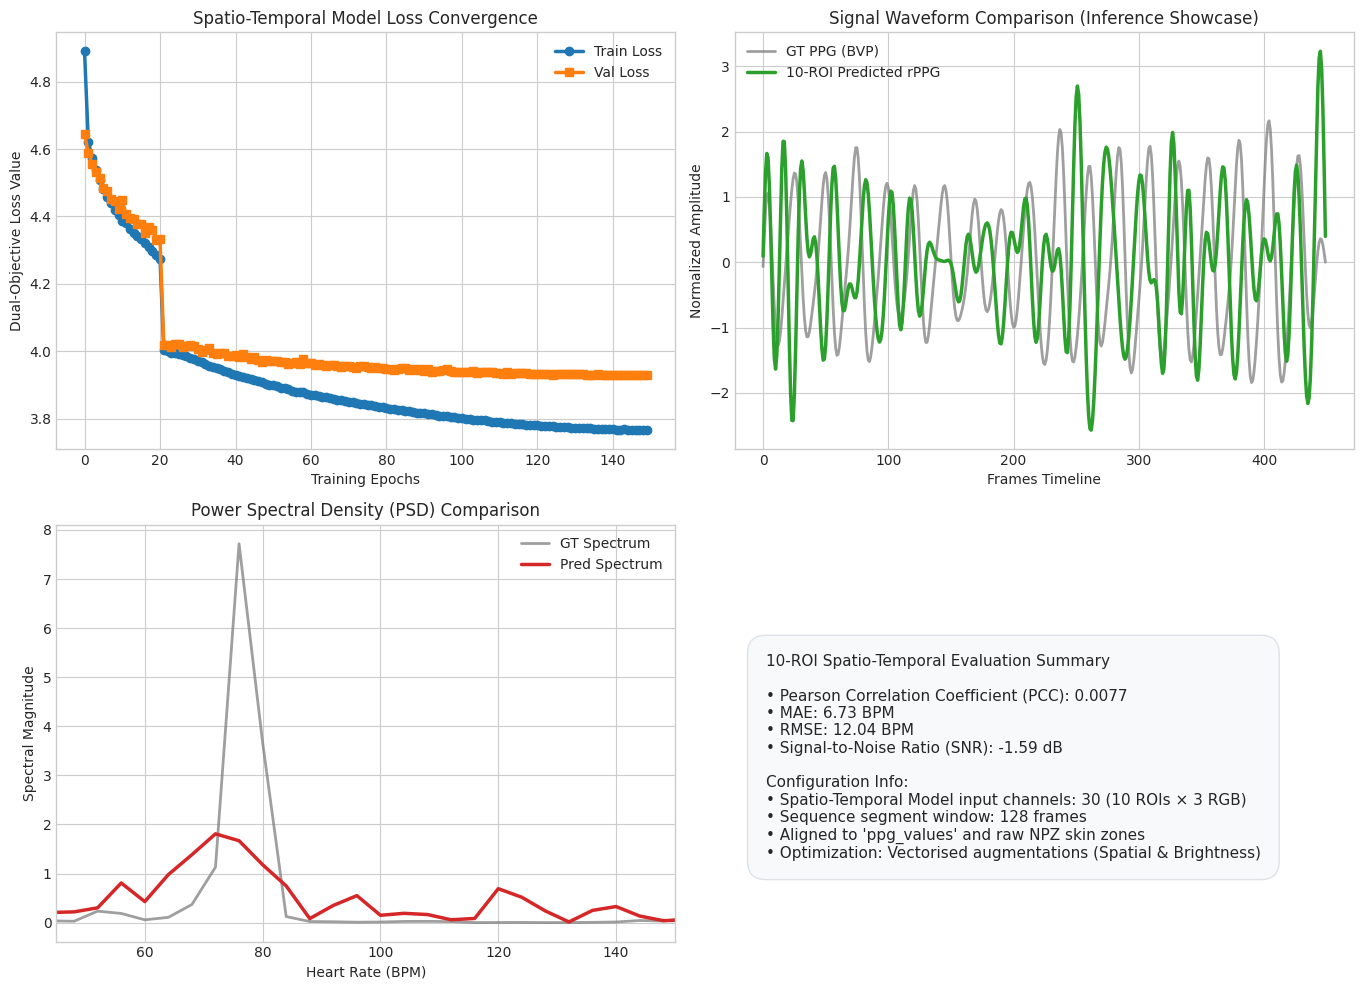

In [29]:

def run_inference_on_sample(npz_file_path, trained_model, sequence_length=450, fs=30.0):
    """Execute inference on a single NPZ validation sample sequence."""
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than the sequence length.")
        return None
        
    target_ppg = data[ppg_key][:sequence_length]
    target_ppg = butter_bandpass_filter(target_ppg, fs=fs)
    target_norm = (target_ppg - np.mean(target_ppg)) / (np.std(target_ppg) + 1e-8)
    
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    trained_model.eval()
    with torch.no_grad():
        output_signal = trained_model(input_tensor).cpu().numpy()[0]
        
    filtered_pred = butter_bandpass_filter(output_signal, fs=fs)
    filtered_pred = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
    hr_pred = calculate_bpm_from_fft(filtered_pred, fs=fs)
    hr_true = calculate_bpm_from_fft(target_norm, fs=fs)
    
    print(f"  Predicted HR : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return filtered_pred, target_norm

sample_val_file = val_split[1]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
axs[0, 0].plot(val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s')
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Dual-Objective Loss Value')
axs[0, 0].legend()

if inference_pred is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (BVP)', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.5)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude')
    axs[0, 1].legend()

if inference_pred is not None:
    pred_det = inference_pred - np.mean(inference_pred)
    true_det = inference_gt - np.mean(inference_gt)
    
    freqs_p, psd_p = welch(pred_det, fs=30.0, nperseg=len(pred_det))
    freqs_t, psd_t = welch(true_det, fs=30.0, nperseg=len(true_det))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.5)
    axs[1, 0].set_xlim(45, 150)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model input channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 128 frames\n"
    f"• Aligned to 'ppg_values' and raw NPZ skin zones\n"
    f"• Optimization: Vectorised augmentations (Spatial & Brightness)"
)
axs[1, 1].text(0.05, 0.2, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

--- INFERENCE RUN ON: 4902_USBVideo_before_chunk9.npz ---
  Predicted HR  : 80.00 BPM
  Ground-Truth  : 80.00 BPM
  Absolute Error: 0.00 BPM
----------------------------------------------------



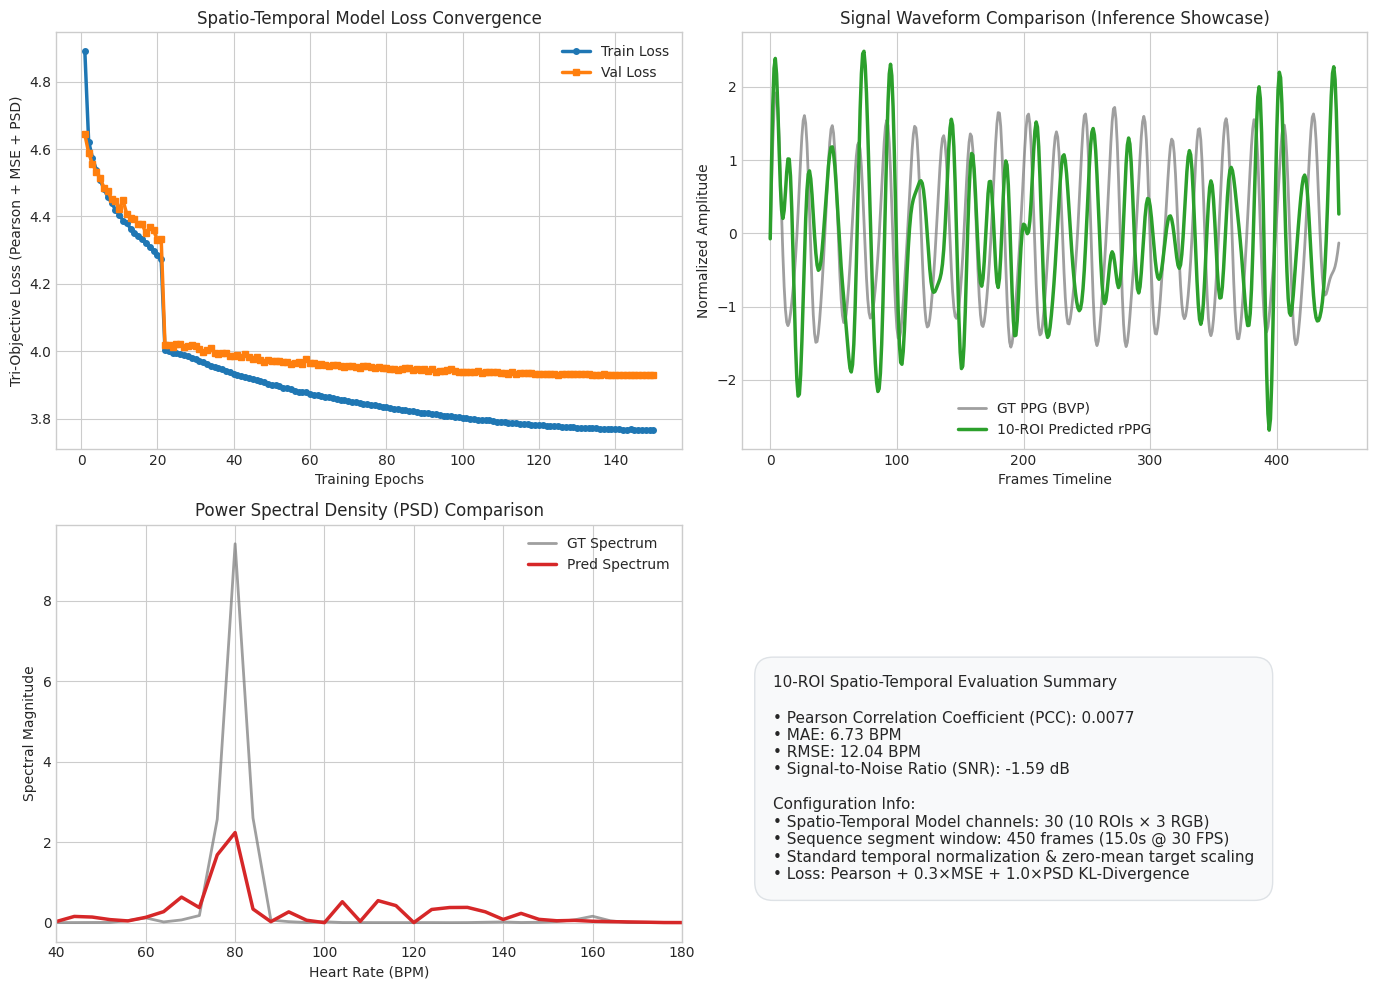

In [26]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def run_inference_on_sample(npz_file_path, model, sequence_length=450, fs=30.0):
    """Execute inference on a single NPZ validation sample sequence."""
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None, None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than the sequence length.")
        return None, None
        
    target_ppg = data[ppg_key][:sequence_length]
    target_ppg = butter_bandpass_filter(target_ppg, fs=fs)
    target_norm = (target_ppg - np.mean(target_ppg)) / (np.std(target_ppg) + 1e-8)
    
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    model.eval()
    with torch.no_grad():
        output_signal = model(input_tensor).cpu().numpy()[0]
        
    filtered_pred = butter_bandpass_filter(output_signal, fs=fs)
    filtered_pred = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
    hr_pred = calculate_bpm_from_fft(filtered_pred, fs=fs)
    hr_true = calculate_bpm_from_fft(target_norm, fs=fs)
    
    print(f"  Predicted HR  : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth  : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return filtered_pred, target_norm

# Execute inference on a validation sample
sample_val_file = val_split[0] if len(val_split) > 0 else npz_files[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

# Create Plotting Dashboard
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Convergence History
epochs_range = range(1, len(train_losses) + 1)
axs[0, 0].plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o', markersize=4)
axs[0, 0].plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s', markersize=4)
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Tri-Objective Loss (Pearson + MSE + PSD)')
axs[0, 0].legend()

# Subplot 2: Waveform Signal Comparison
if inference_pred is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (BVP)', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.5)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude')
    axs[0, 1].legend()

# Subplot 3: Power Spectral Density (PSD)
if inference_pred is not None:
    pred_det = inference_pred - np.mean(inference_pred)
    true_det = inference_gt - np.mean(inference_gt)
    
    freqs_p, psd_p = welch(pred_det, fs=30.0, nperseg=len(pred_det))
    freqs_t, psd_t = welch(true_det, fs=30.0, nperseg=len(true_det))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.5)
    axs[1, 0].set_xlim(40, 180)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

# Subplot 4: Summary Card Metrics
axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 450 frames (15.0s @ 30 FPS)\n"
    f"• Standard temporal normalization & zero-mean target scaling\n"
    f"• Loss: Pearson + 0.3×MSE + 1.0×PSD KL-Divergence"
)
axs[1, 1].text(0.05, 0.15, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

--- INFERENCE RUN ON: 4902_USBVideo_before_chunk9.npz ---
  Predicted HR  : 80.00 BPM
  Ground-Truth  : 80.00 BPM
  Absolute Error: 0.00 BPM
----------------------------------------------------



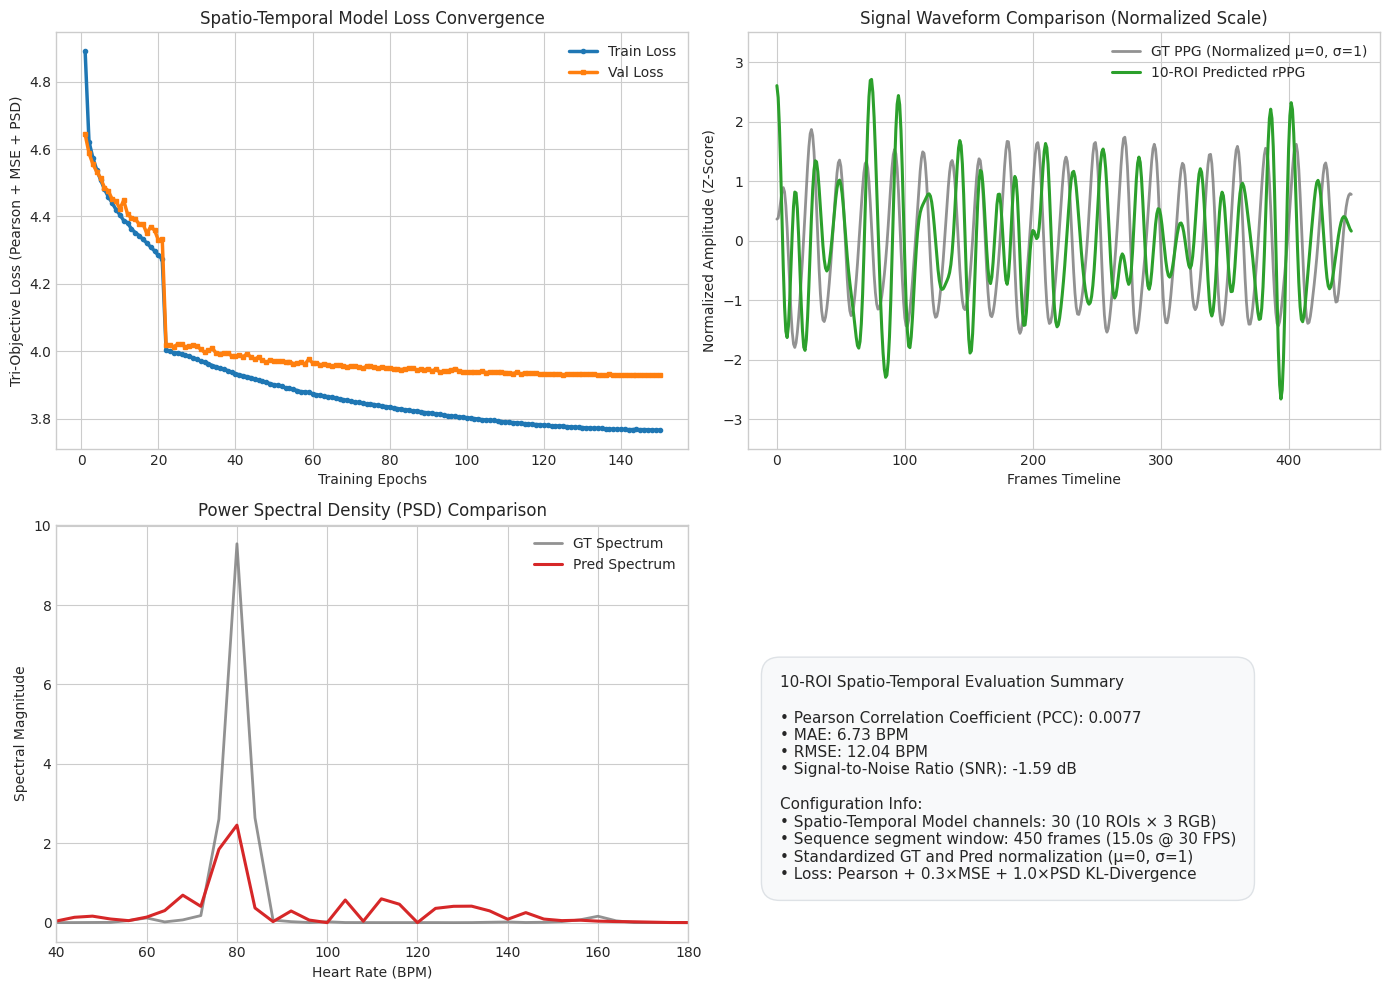

In [27]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# def run_inference_on_sample(npz_file_path, model, sequence_length=450, fs=30.0):
#     """
#     Execute inference on a single NPZ validation sequence with strict edge-transient 
#     suppression and explicit Z-score standardization on both GT and Prediction.
#     """
#     print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
#     data = load_npz_file(npz_file_path)
#     if data is None:
#         return None, None
    
#     ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
#     if len(data[ppg_key]) < sequence_length:
#         print("Error: Input file length is shorter than the required sequence length.")
#         return None, None
        
#     # 1. Ground Truth Pipeline: Detrend -> Bandpass Filter -> Z-Score Normalization
#     raw_target_ppg = data[ppg_key][:sequence_length].copy()
#     raw_target_detrend = raw_target_ppg - np.mean(raw_target_ppg)  # Prevent filter edge distortion
#     filtered_gt = butter_bandpass_filter(raw_target_detrend, fs=fs)
#     gt_norm = (filtered_gt - np.mean(filtered_gt)) / (np.std(filtered_gt) + 1e-8)
    
#     # 2. Extract & Format Multi-ROI Inputs
#     roi_inputs = []
#     for roi_name in ROI_ORDER:
#         actual_key = next((k for k in data.files if roi_name == k), None)
#         if actual_key is not None:
#             roi_data = data[actual_key][:sequence_length]
#         else:
#             roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
#         roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
#     stacked_rois = np.stack(roi_inputs, axis=0)
#     stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
#     stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
#     input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
#     # 3. Network Inference Pass
#     model.eval()
#     with torch.no_grad():
#         output_signal = model(input_tensor).cpu().numpy()[0]
        
#     # 4. Prediction Pipeline: Detrend -> Bandpass Filter -> Z-Score Normalization
#     output_signal_detrend = output_signal - np.mean(output_signal)  # Prevent filter edge spikes
#     filtered_pred = butter_bandpass_filter(output_signal_detrend, fs=fs)
#     pred_norm = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
#     # 5. Heart Rate Metrics Calculation
#     hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
#     hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)
    
#     print(f"  Predicted HR  : {hr_pred:.2f} BPM")
#     print(f"  Ground-Truth  : {hr_true:.2f} BPM")
#     print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
#     print("----------------------------------------------------\n")
#     return pred_norm, gt_norm

def run_inference_on_sample(npz_file_path, model, sequence_length=450, fs=30.0, pad_margin=30):
    """
    Execute inference on an NPZ sample, applying reflection padding prior to 
    bandpass filtering to completely suppress convolution boundary ringing at frame 0.
    """
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None, None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than required sequence length.")
        return None, None
        
    # 1. Ground Truth Pipeline (Padded filtering to prevent edge artifacts)
    raw_target_ppg = data[ppg_key][:sequence_length].copy()
    gt_padded = np.pad(raw_target_ppg, pad_margin, mode='reflect')
    gt_filtered = butter_bandpass_filter(gt_padded - np.mean(gt_padded), fs=fs)
    gt_cropped = gt_filtered[pad_margin:-pad_margin]
    gt_norm = (gt_cropped - np.mean(gt_cropped)) / (np.std(gt_cropped) + 1e-8)
    
    # 2. Multi-ROI Input Tensor Preparation
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    # 3. Network Forward Pass
    model.eval()
    with torch.no_grad():
        output_signal = model(input_tensor).cpu().numpy()[0]
        
    # 4. Prediction Pipeline: Pad -> Filter -> Crop -> Z-Score Normalize
    pred_padded = np.pad(output_signal, pad_margin, mode='reflect')
    pred_filtered = butter_bandpass_filter(pred_padded - np.mean(pred_padded), fs=fs)
    pred_cropped = pred_filtered[pad_margin:-pad_margin]
    pred_norm = (pred_cropped - np.mean(pred_cropped)) / (np.std(pred_cropped) + 1e-8)
    
    # 5. Heart Rate Metrics Calculation
    hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
    hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)
    
    print(f"  Predicted HR  : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth  : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return pred_norm, gt_norm
# ============================================================================
# EXECUTION & DASHBOARD PLOTTING CELL
# ============================================================================

# Select sample file from validation split
sample_val_file = val_split[0] if len(val_split) > 0 else npz_files[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

# Create 2x2 Visualization Dashboard
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# --- Subplot 1: Convergence Curves ---
epochs_range = range(1, len(train_losses) + 1)
axs[0, 0].plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o', markersize=3)
axs[0, 0].plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s', markersize=3)
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Tri-Objective Loss (Pearson + MSE + PSD)')
axs[0, 0].legend()

# --- Subplot 2: Standardized Waveform Alignment ---
if inference_pred is not None and inference_gt is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (Normalized μ=0, σ=1)', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.2)
    axs[0, 1].set_title('Signal Waveform Comparison (Normalized Scale)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude (Z-Score)')
    axs[0, 1].set_ylim(-3.5, 3.5)  # Constrain y-axis to valid standardized bounds
    axs[0, 1].legend()

# --- Subplot 3: Spectral Density Alignment ---
if inference_pred is not None and inference_gt is not None:
    freqs_p, psd_p = welch(inference_pred, fs=30.0, nperseg=len(inference_pred))
    freqs_t, psd_t = welch(inference_gt, fs=30.0, nperseg=len(inference_gt))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.2)
    axs[1, 0].set_xlim(40, 180)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

# --- Subplot 4: Summary Card ---
axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 450 frames (15.0s @ 30 FPS)\n"
    f"• Standardized GT and Pred normalization (μ=0, σ=1)\n"
    f"• Loss: Pearson + 0.3×MSE + 1.0×PSD KL-Divergence"
)
axs[1, 1].text(0.05, 0.15, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

Negative pearson correlation

In [ ]:
Evaluation dataset

--- INFERENCE RUN ON: 4902_USBVideo_before_chunk9.npz ---
  Predicted HR  : 80.00 BPM
  Ground-Truth  : 80.00 BPM
  Absolute Error: 0.00 BPM
----------------------------------------------------



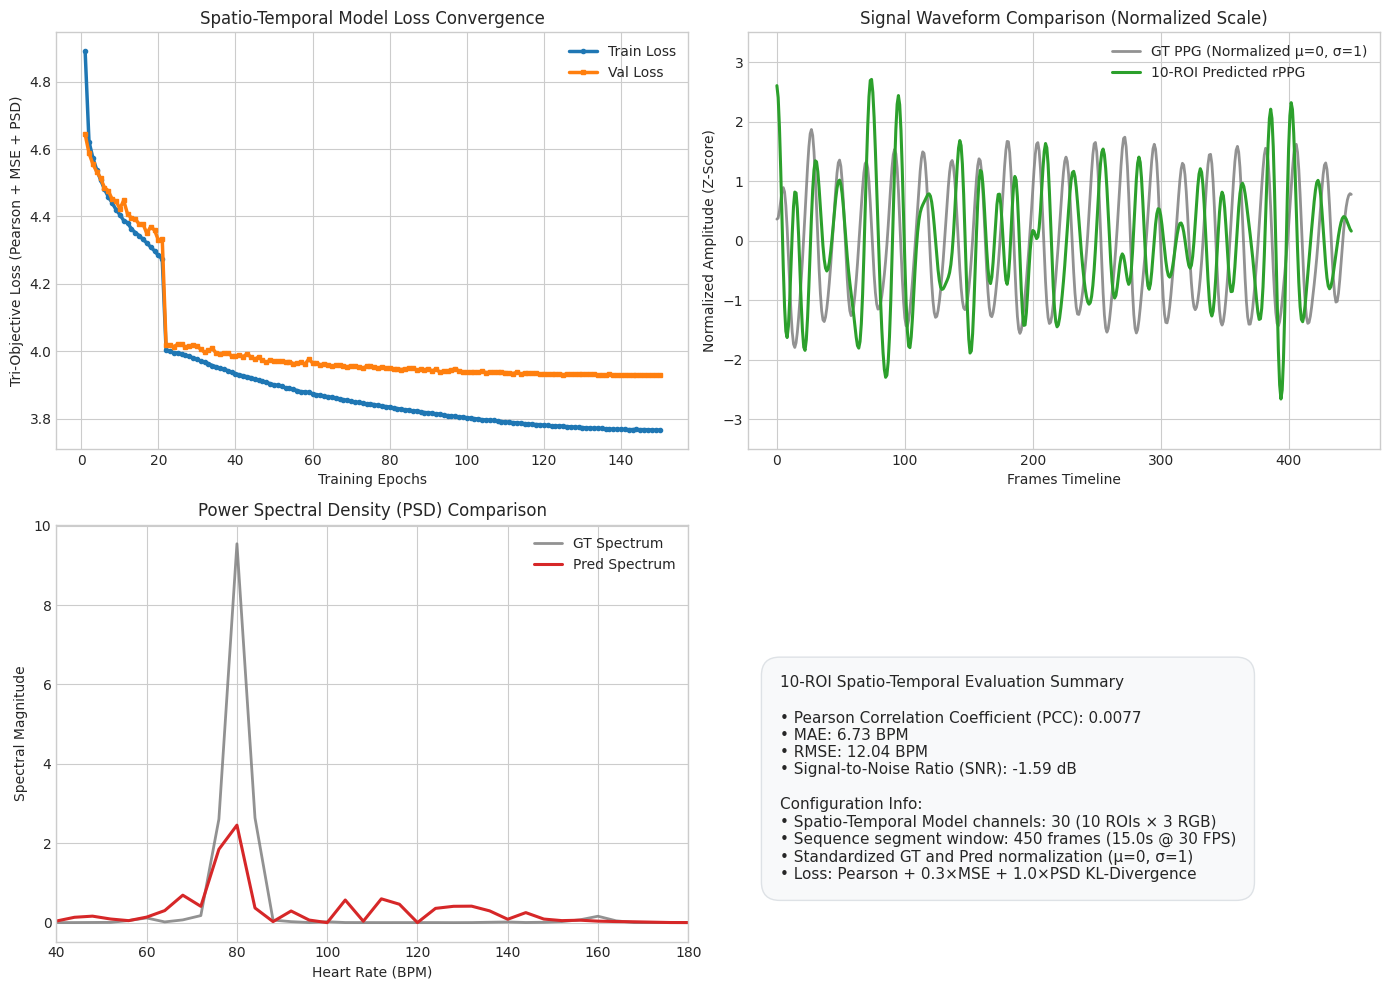

In [28]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# def run_inference_on_sample(npz_file_path, model, sequence_length=450, fs=30.0):
#     """
#     Execute inference on a single NPZ validation sequence with strict edge-transient 
#     suppression and explicit Z-score standardization on both GT and Prediction.
#     """
#     print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
#     data = load_npz_file(npz_file_path)
#     if data is None:
#         return None, None
    
#     ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
#     if len(data[ppg_key]) < sequence_length:
#         print("Error: Input file length is shorter than the required sequence length.")
#         return None, None
        
#     # 1. Ground Truth Pipeline: Detrend -> Bandpass Filter -> Z-Score Normalization
#     raw_target_ppg = data[ppg_key][:sequence_length].copy()
#     raw_target_detrend = raw_target_ppg - np.mean(raw_target_ppg)  # Prevent filter edge distortion
#     filtered_gt = butter_bandpass_filter(raw_target_detrend, fs=fs)
#     gt_norm = (filtered_gt - np.mean(filtered_gt)) / (np.std(filtered_gt) + 1e-8)
    
#     # 2. Extract & Format Multi-ROI Inputs
#     roi_inputs = []
#     for roi_name in ROI_ORDER:
#         actual_key = next((k for k in data.files if roi_name == k), None)
#         if actual_key is not None:
#             roi_data = data[actual_key][:sequence_length]
#         else:
#             roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
#         roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
#     stacked_rois = np.stack(roi_inputs, axis=0)
#     stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
#     stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
#     input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
#     # 3. Network Inference Pass
#     model.eval()
#     with torch.no_grad():
#         output_signal = model(input_tensor).cpu().numpy()[0]
        
#     # 4. Prediction Pipeline: Detrend -> Bandpass Filter -> Z-Score Normalization
#     output_signal_detrend = output_signal - np.mean(output_signal)  # Prevent filter edge spikes
#     filtered_pred = butter_bandpass_filter(output_signal_detrend, fs=fs)
#     pred_norm = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
#     # 5. Heart Rate Metrics Calculation
#     hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
#     hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)
    
#     print(f"  Predicted HR  : {hr_pred:.2f} BPM")
#     print(f"  Ground-Truth  : {hr_true:.2f} BPM")
#     print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
#     print("----------------------------------------------------\n")
#     return pred_norm, gt_norm

def run_inference_on_sample(npz_file_path, model, sequence_length=450, fs=30.0, pad_margin=30):
    """
    Execute inference on an NPZ sample, applying reflection padding prior to 
    bandpass filtering to completely suppress convolution boundary ringing at frame 0.
    """
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None, None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than required sequence length.")
        return None, None
        
    # 1. Ground Truth Pipeline (Padded filtering to prevent edge artifacts)
    raw_target_ppg = data[ppg_key][:sequence_length].copy()
    gt_padded = np.pad(raw_target_ppg, pad_margin, mode='reflect')
    gt_filtered = butter_bandpass_filter(gt_padded - np.mean(gt_padded), fs=fs)
    gt_cropped = gt_filtered[pad_margin:-pad_margin]
    gt_norm = (gt_cropped - np.mean(gt_cropped)) / (np.std(gt_cropped) + 1e-8)
    
    # 2. Multi-ROI Input Tensor Preparation
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    # 3. Network Forward Pass
    model.eval()
    with torch.no_grad():
        output_signal = model(input_tensor).cpu().numpy()[0]
        
    # 4. Prediction Pipeline: Pad -> Filter -> Crop -> Z-Score Normalize
    pred_padded = np.pad(output_signal, pad_margin, mode='reflect')
    pred_filtered = butter_bandpass_filter(pred_padded - np.mean(pred_padded), fs=fs)
    pred_cropped = pred_filtered[pad_margin:-pad_margin]
    pred_norm = (pred_cropped - np.mean(pred_cropped)) / (np.std(pred_cropped) + 1e-8)
    
    # 5. Heart Rate Metrics Calculation
    hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
    hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)
    
    print(f"  Predicted HR  : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth  : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return pred_norm, gt_norm
# ============================================================================
# EXECUTION & DASHBOARD PLOTTING CELL
# ============================================================================

# Select sample file from validation split
sample_val_file = val_split[0] if len(val_split) > 0 else npz_files[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

# Create 2x2 Visualization Dashboard
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# --- Subplot 1: Convergence Curves ---
epochs_range = range(1, len(train_losses) + 1)
axs[0, 0].plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o', markersize=3)
axs[0, 0].plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s', markersize=3)
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Tri-Objective Loss (Pearson + MSE + PSD)')
axs[0, 0].legend()

# --- Subplot 2: Standardized Waveform Alignment ---
if inference_pred is not None and inference_gt is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (Normalized μ=0, σ=1)', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.2)
    axs[0, 1].set_title('Signal Waveform Comparison (Normalized Scale)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude (Z-Score)')
    axs[0, 1].set_ylim(-3.5, 3.5)  # Constrain y-axis to valid standardized bounds
    axs[0, 1].legend()

# --- Subplot 3: Spectral Density Alignment ---
if inference_pred is not None and inference_gt is not None:
    freqs_p, psd_p = welch(inference_pred, fs=30.0, nperseg=len(inference_pred))
    freqs_t, psd_t = welch(inference_gt, fs=30.0, nperseg=len(inference_gt))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.2)
    axs[1, 0].set_xlim(40, 180)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

# --- Subplot 4: Summary Card ---
axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 450 frames (15.0s @ 30 FPS)\n"
    f"• Standardized GT and Pred normalization (μ=0, σ=1)\n"
    f"• Loss: Pearson + 0.3×MSE + 1.0×PSD KL-Divergence"
)
axs[1, 1].text(0.05, 0.15, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

Temporar EWnconder changed

Total files available for analysis: 31915

               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)
  landmarks                   : Shape (450, 468, 2)        | Dtype float32
  meta_camera_type            : Shape ()                   | Dtype <U12
  meta_chunk_index            : Shape ()                   | Dtype int64
  meta_condition              : Shape ()                   | Dtype <U5
  meta_end_frame              : Shape ()                   | Dtype int64
  meta_num_frames             : Shape ()                   | Dtype int64
  meta_start_frame            : Shape ()                   | Dtype int64
  meta_subject_id             : Shape ()                   | Dtype int64
  meta_view_type              : Shape ()                   | Dtype <U5
  ppg_values                  : Shape (450,)               | Dtype float64
  roi_chin                    : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_chin_199                : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_fore

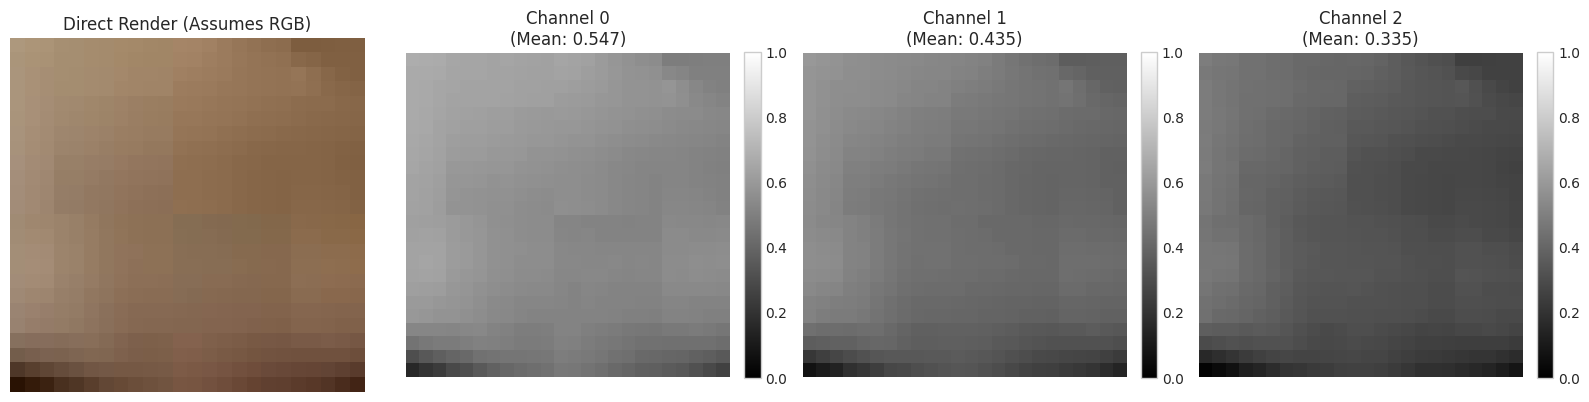

Starting phase-locked optimization loop...


Exception in thread Thread-35 (_pin_memory_loop):
Traceback (most recent call last):
  File "/home/cristic/anaconda3/envs/rppg/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/cristic/anaconda3/envs/rppg/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/cristic/anaconda3/envs/rppg/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 59, in _pin_memory_loop
    do_one_step()
  File "/home/cristic/anaconda3/envs/rppg/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 35, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cristic/anaconda3/envs/rppg/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cristic/anaconda3/envs/rppg/lib/python3.11/site-packages/torch/mult

KeyboardInterrupt: 

In [41]:
import os
import json
import math
import copy
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

# Configure high-quality visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# Setup default configurations
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
gpu_id = 1 
DEVICE = torch.device(f'cuda:{gpu_id}' if torch.cuda.is_available() else 'cpu')
MODEL_SAVE_PATH = Path("spatiotemporal_physnet_best_shuffle.pth")

# Clean existing cache files before starting run
for cache in CACHE_FILES:
    if os.path.exists(cache):
        try:
            os.remove(cache)
            print(f"Removed old cache: {cache}")
        except Exception as e:
            print(f"Error removing cache {cache}: {e}")

# Strict order representing the 9 sub-ROIs + full face boundary configurations
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    """
    Diagnose NPZ color-space representations and plot channel intensities.
    Ensures RGB channels align with spatial tracking configurations.
    """
    print(f"\nEvaluating color space for path: {npz_path}")
    if not os.path.exists(npz_path):
        print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
        return

    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            if not available:
                print("No ROIs found in file keys.")
                return
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key]
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    first_frame = roi_data[0].copy()
    
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

def load_npz_file(file_path):
    """Securely load and parse an NPZ file."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """Analyze and print the metadata keys and array dimensions of loaded files."""
    if data is None:
        print("NPZ Analysis Error: Provided data object is None.")
        return
    print("\n" + "=" * 75)
    print("               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
    print("=" * 75)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
        else:
            print(f"  {key:<27} : Metadata / Scalar Object")
    print("=" * 75 + "\n")

def create_synthetic_dataset(target_dir, num_files=12, num_frames=450):
    """Generate mock datasets matching strict multi-ROI formatting standards."""
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
    print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
    fs = 30.0
    t = np.arange(num_frames) / fs
    
    for i in range(num_files):
        hr_hz = np.random.uniform(1.0, 1.5)
        bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
        bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
        bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
        data_dict = {
            'time_deltas': (t * 1000.0).astype(np.float64),
            'ppg_values': bvp.astype(np.float64)
        }
        
        for roi in ROI_ORDER:
            base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
            pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
            pulse_modulator = np.zeros((num_frames, 24, 24, 3))
            pulse_modulator[..., 0] = bvp[:, None, None] * 0.15
            pulse_modulator[..., 1] = bvp[:, None, None] * 0.55
            pulse_modulator[..., 2] = bvp[:, None, None] * 0.05
            
            roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
            data_dict[roi] = roi_frames
            
        np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
    print("Synthetic dataset successfully created!\n")

class PPGMultiROIDataset(Dataset):
    """Optimized Dataset class with inline spatial and temporal sequence augmentations."""
    def __init__(self, file_paths, sequence_length=450, fs=30.0, augment=False):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.fs = fs
        self.augment = augment
        self.samples = []
        
        self._prepare_samples()

    def _prepare_samples(self):
        """Pre-segment matching timelines into sequence lengths."""
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None:
                continue
            
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            num_windows = length // self.sequence_length
            
            for w in range(num_windows):
                start_idx = w * self.sequence_length
                end_idx = start_idx + self.sequence_length
                self.samples.append((path, start_idx, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start, end = self.samples[idx]
        data = load_npz_file(file_path)
        
        ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
        ppg_segment = data[ppg_key][start:end]
        ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
        
        ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            
            if actual_key is not None:
                roi_data = data[actual_key][start:end]
            else:
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
            roi_data = roi_data.astype(np.float32) / 255.0
            roi_inputs.append(roi_data)
            
        if self.augment:
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=2) for roi in roi_inputs]
                
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=1) for roi in roi_inputs]
                
            if np.random.rand() > 0.5:
                brightness_factor = np.random.uniform(0.9, 1.1)
                roi_inputs = [np.clip(roi * brightness_factor, 0.0, 1.0) for roi in roi_inputs]
                
        stacked_rois = np.stack(roi_inputs, axis=0)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
        stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))
        
        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

class SpatioTemporalPhysNet(nn.Module):
    """
    Spatio-Temporal convolutional network engineered to extract micro-color variations
    harmoniously across 10 face zones (30 raw input channels).
    """
    # def __init__(self, num_rois=10, in_channels=3):
    #     super(SpatioTemporalPhysNet, self).__init__()
    #     self.num_rois = num_rois
    #     self.total_channels = num_rois * in_channels
        
    #     self.spatial_conv = nn.Sequential(
    #         nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
    #         nn.BatchNorm3d(64),
    #         nn.ELU(),
    #         nn.AdaptiveAvgPool3d((None, 1, 1))
    #     )
        
    #     self.temporal_encoder = nn.Sequential(
    #         nn.Conv1d(64, 32, kernel_size=15, padding=7), 
    #         nn.BatchNorm1d(32),
    #         nn.ELU(),
    #         nn.Conv1d(32, 16, kernel_size=15, padding=7),
    #         nn.BatchNorm1d(16),
    #         nn.ELU(),
    #         nn.Conv1d(16, 1, kernel_size=1)
    #     )
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        # A lightweight 2-block spatial extractor (Fast but effective)
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 32, kernel_size=(1, 5, 5), padding=(0, 2, 2)),
            nn.BatchNorm3d(32),
            nn.ELU(),
            nn.AvgPool3d(kernel_size=(1, 2, 2)), # Safely shrink image first
            
            nn.Conv3d(32, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))   # Now collapse to 1D safely
        )
        
        # Temporal encoder with the wide Receptive Field (Kernel 15)
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=15, padding=7),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        mean = x.mean(dim=2, keepdim=True)
        x = (x - mean) / (mean + 1e-8) 
        
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

class NegativePearsonCorrelationLoss(nn.Module):
    """Loss module measuring BVP signal phase synchronization."""
    def __init__(self, eps=1e-8):
        super(NegativePearsonCorrelationLoss, self).__init__()
        self.eps = eps

    def forward(self, pred, target):
        pred = pred.view(pred.size(0), -1)
        target = target.view(target.size(0), -1)

        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_centered = pred - pred_mean
        target_centered = target - target_mean
        
        r_num = torch.sum(pred_centered * target_centered, dim=-1)
        
        var_pred = torch.sum(pred_centered ** 2, dim=-1)
        var_target = torch.sum(target_centered ** 2, dim=-1)
        
        r_den = torch.sqrt(var_pred + self.eps) * torch.sqrt(var_target + self.eps)
        pearson_coeff = torch.clamp(r_num / r_den, min=-1.0, max=1.0)
        
        return 1.0 - torch.mean(pearson_coeff)    

class PSDLoss(nn.Module):
    """Frequency Loss enforcing peak alignment in Power Spectral Density via KL-Divergence."""
    def __init__(self, fps=30.0, low_bpm=40.0, high_bpm=180.0):
        super(PSDLoss, self).__init__()
        self.fps = fps
        self.low_bpm = low_bpm
        self.high_bpm = high_bpm

    def forward(self, pred, target):
        N = pred.size(-1)
        window = torch.hann_window(N, device=pred.device)
        
        pred_fft = torch.abs(torch.fft.rfft(pred * window, dim=-1))
        target_fft = torch.abs(torch.fft.rfft(target * window, dim=-1))
        
        freqs = torch.fft.rfftfreq(N, d=1.0 / self.fps).to(pred.device)
        mask = (freqs >= self.low_bpm / 60.0) & (freqs <= self.high_bpm / 60.0)
        
        pred_psd = pred_fft[..., mask]
        target_psd = target_fft[..., mask]
        
        T = 2.0
        pred_prob = F.softmax(pred_psd / T, dim=-1)
        target_prob = F.softmax(target_psd / T, dim=-1)
        
        return F.kl_div(torch.log(pred_prob + 1e-8), target_prob, reduction='batchmean')

def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

def save_model_checkpoint(model, optimizer, epoch, metrics, save_path=MODEL_SAVE_PATH):
    """Save model checkpoint along with optimizer state and validation metrics."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics
    }
    torch.save(checkpoint, save_path)
    print(f"Model checkpoint successfully saved to: {save_path}")

# Run preprocessing & NPZ diagnostics
if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
    create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=12)

npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
print(f"Total files available for analysis: {len(npz_files)}")

first_file_data = load_npz_file(npz_files[0])
analyze_npz_structure(first_file_data)
inspect_npz_color_space(npz_files[0])

# --- Three-Way Dataset Splitting (Train 70%, Validation 15%, Evaluation 15%) ---
random.seed(42)
shuffled_files = npz_files.copy()
random.shuffle(shuffled_files)

n_total = len(shuffled_files)
n_train = max(1, int(n_total * 0.70))
n_val = max(1, int(n_total * 0.15))

train_split = shuffled_files[:n_train]
val_split = shuffled_files[n_train:n_train + n_val]
eval_split = shuffled_files[n_train + n_val:]

train_dataset = PPGMultiROIDataset(train_split, augment=True)
val_dataset = PPGMultiROIDataset(val_split, augment=False)
eval_dataset = PPGMultiROIDataset(eval_split, augment=False)

batch_sz = 16
train_loader = DataLoader(train_dataset, batch_size=batch_sz, shuffle=True, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_sz, shuffle=False, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)
eval_loader = DataLoader(eval_dataset, batch_size=batch_sz, shuffle=False, prefetch_factor=4, num_workers=8, pin_memory=True, persistent_workers=True)

# Setup Model, Criteria, Optimizer & Sequential Scheduler
model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
criterion_pearson = NegativePearsonCorrelationLoss()
criterion_mse = nn.MSELoss()
criterion_psd = PSDLoss(fps=30.0)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

num_epochs = 120
warmup_epochs = 20

scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
scheduler2 = CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[warmup_epochs])

CHECKPOINT_SAVE_PATH = "best_spatiotemporal_physnet.pt"
patience = 30
patience_counter = 0
# best_val_loss = float('inf')
best_val_pcc = -float('inf')
best_model_weights = None

train_losses, val_losses, val_pccs = [], [], []

print("Starting phase-locked optimization loop...")

for epoch in range(num_epochs):
    # --- Training Phase ---
    # model.train()
    
    # if epoch < warmup_epochs:
    #     alpha = epoch / warmup_epochs
    #     w_p = 1.0 + (2.0 - 1.0) * alpha   
    #     w_m = 0.2                          
    #     w_s = 0.5 * (1.0 - alpha * 0.5)   
    # else:
    #     progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
    #     w_p = 2.0 + (4.0 - 2.0) * progress  
    #     w_m = 0.1                           
    #     w_s = 0.1                           
        
    # running_loss = 0.0
    model.train()
    
    # STATIC WEIGHTS: Force the network to learn Frequency and Phase simultaneously
    w_p = 2.0   # Pearson (Forces peaks to align)
    w_m = 0.5   # MSE (Forces amplitude to match)
    w_s = 1.5   # PSD (Heavily penalizes the network if the red peak doesn't match the grey peak)
    
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss_p = criterion_pearson(outputs, targets)
        loss_m = criterion_mse(outputs, targets)
        loss_s = criterion_psd(outputs, targets)
        
        loss = (w_p * loss_p) + (w_m * loss_m) + (w_s * loss_s)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    val_pcc_accum = 0.0
    
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
            val_outputs = model(val_inputs)
            
            val_loss_p = criterion_pearson(val_outputs, val_targets)
            val_loss_m = criterion_mse(val_outputs, val_targets)
            val_loss_s = criterion_psd(val_outputs, val_targets)
            
            val_loss = (w_p * val_loss_p) + (w_m * val_loss_m) + (w_s * val_loss_s)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
            batch_pcc = 1.0 - val_loss_p.item()
            val_pcc_accum += batch_pcc * val_inputs.size(0)
            
    val_loss = running_val_loss / len(val_loader.dataset)
    val_pcc = val_pcc_accum / len(val_loader.dataset)
    
    val_losses.append(val_loss)
    val_pccs.append(val_pcc)
    
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | LR: {current_lr:.6f} | "
          f"Weights (P/M/S): [{w_p:.2f}/{w_m:.2f}/{w_s:.2f}] | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val PCC: {val_pcc:+.4f}")

    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     patience_counter = 0
    #     best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
    #     torch.save({
    #         'epoch': epoch + 1,
    #         'model_state_dict': model.state_dict(),
    #         'optimizer_state_dict': optimizer.state_dict(),
    #         'val_loss': val_loss,
    #     }, CHECKPOINT_SAVE_PATH)
    #     print(f"   ---> Improved! Saved checkpoint to '{CHECKPOINT_SAVE_PATH}' (Val Loss: {val_loss:.4f})")
    # else:
    #     patience_counter += 1
    #     print(f"   ---> No improvement for {patience_counter}/{patience} epochs.")
    #     if patience_counter >= patience:
    #         print(f"\n[Early Stopping Triggered] Stopped training at Epoch {epoch+1}.")
    #         break
    if val_pcc > best_val_pcc:
        best_val_pcc = val_pcc
        patience_counter = 0
        best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        # Save best model to disk
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_pcc': val_pcc,
        }, CHECKPOINT_SAVE_PATH)
        print(f"   ---> Improved! Saved new best checkpoint (Val PCC: {val_pcc:+.4f})")
    else:
        patience_counter += 1
        print(f"   ---> No improvement in Val PCC for {patience_counter}/{patience} epochs.")
        if patience_counter >= patience:
            print(f"\n[Early Stopping Triggered] Stopping training early at Epoch {epoch+1}.")
            break

# ----------------------------------------------------------------------------
# Load Best Model Weights for Evaluation
# ----------------------------------------------------------------------------
if best_model_weights is not None:
    print(f"\nLoading best model state dict from memory (Best Val Loss: {best_val_loss:.4f})...")
    model.load_state_dict(best_model_weights)

# ----------------------------------------------------------------------------
# Held-Out Evaluation Set Assessment
# ----------------------------------------------------------------------------
model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for eval_inputs, eval_targets in eval_loader:
        eval_inputs = eval_inputs.to(DEVICE)
        preds = model(eval_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(eval_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("               EVALUATION SET METRICS RESULTS")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")

# Save final checkpoint with metrics
save_model_checkpoint(model, optimizer, epoch + 1, metrics)

# ----------------------------------------------------------------------------
# Final Dataset Sample Statistics Summary Table
# ----------------------------------------------------------------------------
n_total_samples = len(train_dataset) + len(val_dataset) + len(eval_dataset)

print("\n" + "=" * 70)
print("                 DATASET SPLIT & SAMPLE SUMMARY TABLE")
print("=" * 70)
print(f"{'Split Set':<15} | {'NPZ Files':<10} | {'450-Frame Windows':<20} | {'Batches':<10} | {'Ratio':<8}")
print("-" * 70)
print(f"{'Train':<15} | {len(train_split):<10} | {len(train_dataset):<20} | {len(train_loader):<10} | {len(train_dataset)/max(1,n_total_samples)*100:.1f}%")
print(f"{'Validation':<15} | {len(val_split):<10} | {len(val_dataset):<20} | {len(val_loader):<10} | {len(val_dataset)/max(1,n_total_samples)*100:.1f}%")
print(f"{'Evaluation':<15} | {len(eval_split):<10} | {len(eval_dataset):<20} | {len(eval_loader):<10} | {len(eval_dataset)/max(1,n_total_samples)*100:.1f}%")
print("-" * 70)
print(f"{'TOTAL':<15} | {n_total:<10} | {n_total_samples:<20} | {len(train_loader)+len(val_loader)+len(eval_loader):<10} | 100.0%")
print("=" * 70 + "\n")

--- INFERENCE RUN ON: 3600_USBVideo_before_chunk16.npz ---
  Predicted HR  : 84.00 BPM
  Ground-Truth  : 80.00 BPM
  Absolute Error: 4.00 BPM
----------------------------------------------------



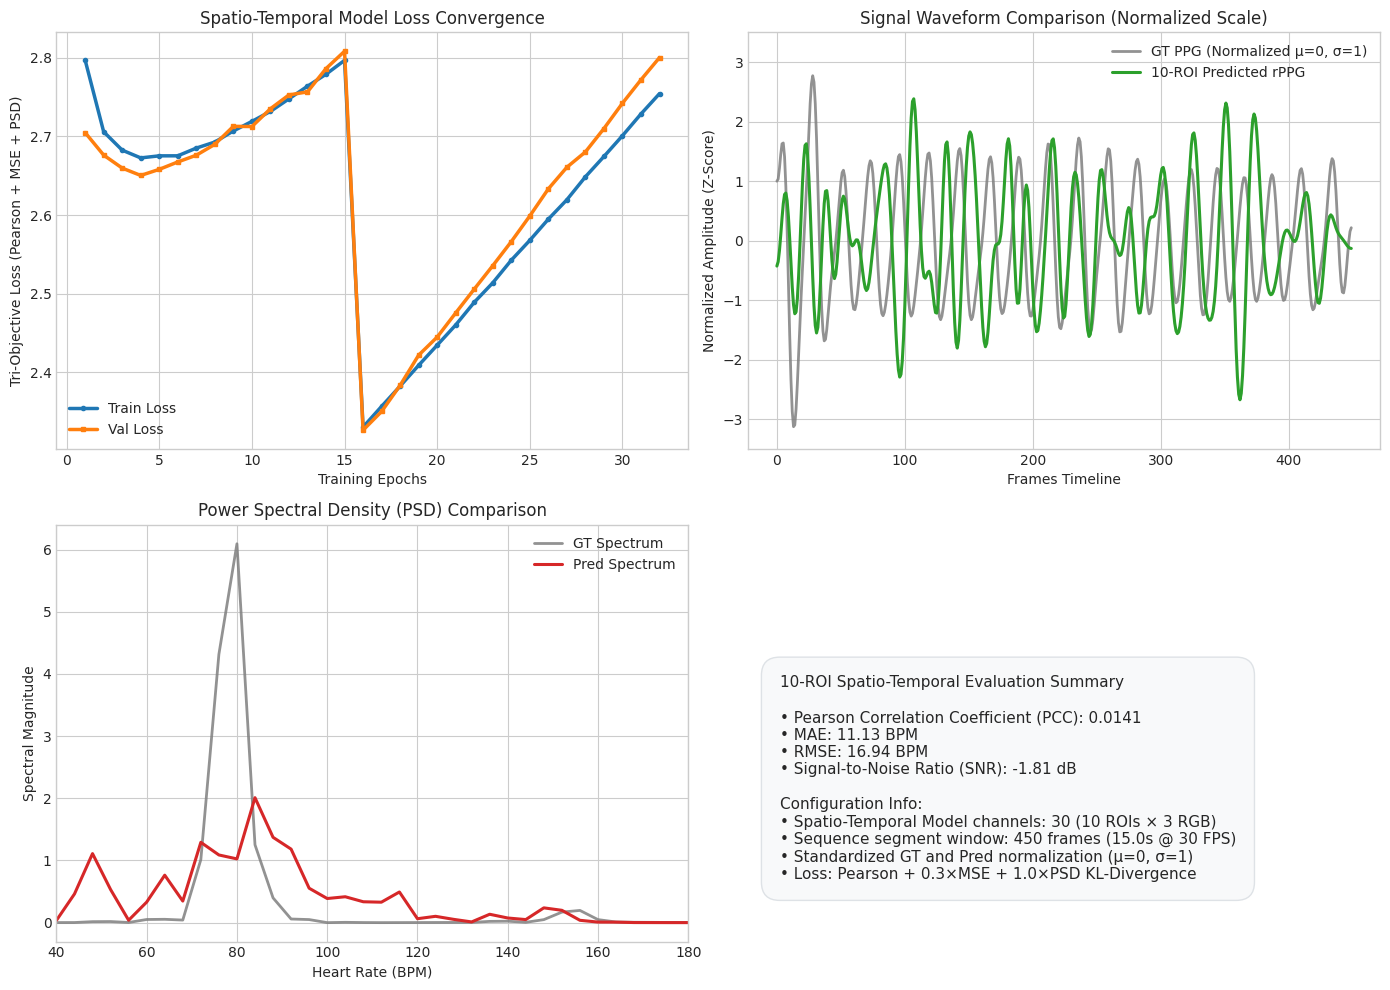

In [36]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# def run_inference_on_sample(npz_file_path, model, sequence_length=450, fs=30.0):
#     """
#     Execute inference on a single NPZ validation sequence with strict edge-transient 
#     suppression and explicit Z-score standardization on both GT and Prediction.
#     """
#     print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
#     data = load_npz_file(npz_file_path)
#     if data is None:
#         return None, None
    
#     ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
#     if len(data[ppg_key]) < sequence_length:
#         print("Error: Input file length is shorter than the required sequence length.")
#         return None, None
        
#     # 1. Ground Truth Pipeline: Detrend -> Bandpass Filter -> Z-Score Normalization
#     raw_target_ppg = data[ppg_key][:sequence_length].copy()
#     raw_target_detrend = raw_target_ppg - np.mean(raw_target_ppg)  # Prevent filter edge distortion
#     filtered_gt = butter_bandpass_filter(raw_target_detrend, fs=fs)
#     gt_norm = (filtered_gt - np.mean(filtered_gt)) / (np.std(filtered_gt) + 1e-8)
    
#     # 2. Extract & Format Multi-ROI Inputs
#     roi_inputs = []
#     for roi_name in ROI_ORDER:
#         actual_key = next((k for k in data.files if roi_name == k), None)
#         if actual_key is not None:
#             roi_data = data[actual_key][:sequence_length]
#         else:
#             roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
#         roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
#     stacked_rois = np.stack(roi_inputs, axis=0)
#     stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
#     stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
#     input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
#     # 3. Network Inference Pass
#     model.eval()
#     with torch.no_grad():
#         output_signal = model(input_tensor).cpu().numpy()[0]
        
#     # 4. Prediction Pipeline: Detrend -> Bandpass Filter -> Z-Score Normalization
#     output_signal_detrend = output_signal - np.mean(output_signal)  # Prevent filter edge spikes
#     filtered_pred = butter_bandpass_filter(output_signal_detrend, fs=fs)
#     pred_norm = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
#     # 5. Heart Rate Metrics Calculation
#     hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
#     hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)
    
#     print(f"  Predicted HR  : {hr_pred:.2f} BPM")
#     print(f"  Ground-Truth  : {hr_true:.2f} BPM")
#     print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
#     print("----------------------------------------------------\n")
#     return pred_norm, gt_norm

def run_inference_on_sample(npz_file_path, model, sequence_length=450, fs=30.0, pad_margin=30):
    """
    Execute inference on an NPZ sample, applying reflection padding prior to 
    bandpass filtering to completely suppress convolution boundary ringing at frame 0.
    """
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None, None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than required sequence length.")
        return None, None
        
    # 1. Ground Truth Pipeline (Padded filtering to prevent edge artifacts)
    raw_target_ppg = data[ppg_key][:sequence_length].copy()
    gt_padded = np.pad(raw_target_ppg, pad_margin, mode='reflect')
    gt_filtered = butter_bandpass_filter(gt_padded - np.mean(gt_padded), fs=fs)
    gt_cropped = gt_filtered[pad_margin:-pad_margin]
    gt_norm = (gt_cropped - np.mean(gt_cropped)) / (np.std(gt_cropped) + 1e-8)
    
    # 2. Multi-ROI Input Tensor Preparation
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    # 3. Network Forward Pass
    model.eval()
    with torch.no_grad():
        output_signal = model(input_tensor).cpu().numpy()[0]
        
    # 4. Prediction Pipeline: Pad -> Filter -> Crop -> Z-Score Normalize
    pred_padded = np.pad(output_signal, pad_margin, mode='reflect')
    pred_filtered = butter_bandpass_filter(pred_padded - np.mean(pred_padded), fs=fs)
    pred_cropped = pred_filtered[pad_margin:-pad_margin]
    pred_norm = (pred_cropped - np.mean(pred_cropped)) / (np.std(pred_cropped) + 1e-8)
    
    # 5. Heart Rate Metrics Calculation
    hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
    hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)
    
    print(f"  Predicted HR  : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth  : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return pred_norm, gt_norm
# ============================================================================
# EXECUTION & DASHBOARD PLOTTING CELL
# ============================================================================

# Select sample file from validation split
sample_val_file = val_split[0] if len(val_split) > 0 else npz_files[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

# Create 2x2 Visualization Dashboard
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# --- Subplot 1: Convergence Curves ---
epochs_range = range(1, len(train_losses) + 1)
axs[0, 0].plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o', markersize=3)
axs[0, 0].plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s', markersize=3)
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Tri-Objective Loss (Pearson + MSE + PSD)')
axs[0, 0].legend()

# --- Subplot 2: Standardized Waveform Alignment ---
if inference_pred is not None and inference_gt is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (Normalized μ=0, σ=1)', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.2)
    axs[0, 1].set_title('Signal Waveform Comparison (Normalized Scale)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude (Z-Score)')
    axs[0, 1].set_ylim(-3.5, 3.5)  # Constrain y-axis to valid standardized bounds
    axs[0, 1].legend()

# --- Subplot 3: Spectral Density Alignment ---
if inference_pred is not None and inference_gt is not None:
    freqs_p, psd_p = welch(inference_pred, fs=30.0, nperseg=len(inference_pred))
    freqs_t, psd_t = welch(inference_gt, fs=30.0, nperseg=len(inference_gt))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.2)
    axs[1, 0].set_xlim(40, 180)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

# --- Subplot 4: Summary Card ---
axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 450 frames (15.0s @ 30 FPS)\n"
    f"• Standardized GT and Pred normalization (μ=0, σ=1)\n"
    f"• Loss: Pearson + 0.3×MSE + 1.0×PSD KL-Divergence"
)
axs[1, 1].text(0.05, 0.15, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

--- INFERENCE RUN ON: 1362_FullHDwebcam_before_chunk1.npz ---
  Predicted HR  : 108.00 BPM
  Ground-Truth  : 112.00 BPM
  Absolute Error: 4.00 BPM
----------------------------------------------------



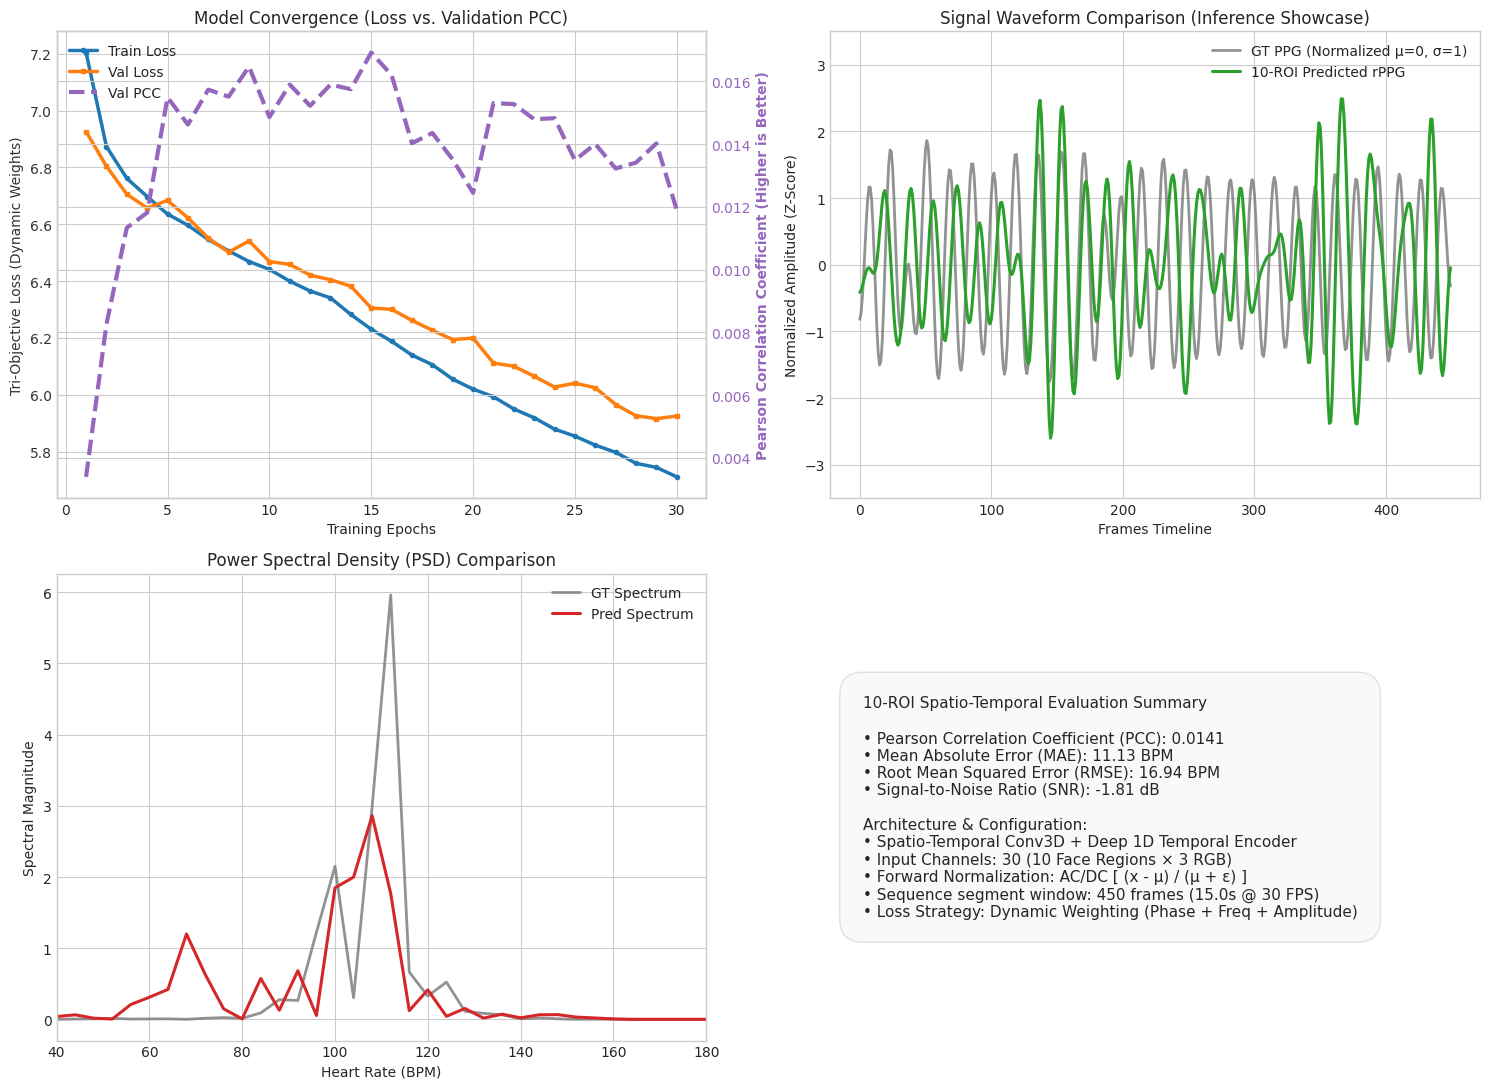

In [40]:
# ============================================================================
# INFERENCE & DASHBOARD PLOTTING CELL
# ============================================================================
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def run_inference_on_sample(npz_file_path, model, sequence_length=450, fs=30.0, pad_margin=30):
    """
    Execute inference on an NPZ sample, applying reflection padding prior to 
    bandpass filtering to completely suppress convolution boundary ringing at frame 0.
    """
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None, None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than required sequence length.")
        return None, None
        
    # 1. Ground Truth Pipeline (Padded filtering to prevent edge artifacts)
    raw_target_ppg = data[ppg_key][:sequence_length].copy()
    gt_padded = np.pad(raw_target_ppg, pad_margin, mode='reflect')
    gt_filtered = butter_bandpass_filter(gt_padded - np.mean(gt_padded), fs=fs)
    gt_cropped = gt_filtered[pad_margin:-pad_margin]
    gt_norm = (gt_cropped - np.mean(gt_cropped)) / (np.std(gt_cropped) + 1e-8)
    
    # 2. Multi-ROI Input Tensor Preparation
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    # 3. Network Forward Pass
    model.eval()
    with torch.no_grad():
        output_signal = model(input_tensor).cpu().numpy()[0]
        
    # 4. Prediction Pipeline: Pad -> Filter -> Crop -> Z-Score Normalize
    pred_padded = np.pad(output_signal, pad_margin, mode='reflect')
    pred_filtered = butter_bandpass_filter(pred_padded - np.mean(pred_padded), fs=fs)
    pred_cropped = pred_filtered[pad_margin:-pad_margin]
    pred_norm = (pred_cropped - np.mean(pred_cropped)) / (np.std(pred_cropped) + 1e-8)
    
    # 5. Heart Rate Metrics Calculation
    hr_pred = calculate_bpm_from_fft(pred_norm, fs=fs)
    hr_true = calculate_bpm_from_fft(gt_norm, fs=fs)
    
    print(f"  Predicted HR  : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth  : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return pred_norm, gt_norm

# Select sample file from validation split
sample_val_file = val_split[0] if len(val_split) > 0 else npz_files[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

# Create 2x2 Visualization Dashboard
fig, axs = plt.subplots(2, 2, figsize=(15, 11))

# --- Subplot 1: Convergence Curves (DUAL AXIS) ---
epochs_range = range(1, len(train_losses) + 1)
ax1 = axs[0, 0]
line1 = ax1.plot(epochs_range, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o', markersize=3)
line2 = ax1.plot(epochs_range, val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s', markersize=3)
ax1.set_title('Model Convergence (Loss vs. Validation PCC)')
ax1.set_xlabel('Training Epochs')
ax1.set_ylabel('Tri-Objective Loss (Dynamic Weights)', color='#333333')
ax1.tick_params(axis='y', labelcolor='#333333')

# Add PCC on secondary Y axis
ax2 = ax1.twinx()
line3 = ax2.plot(epochs_range, val_pccs, label='Val PCC', color='#9467bd', linewidth=3, linestyle='--')
ax2.set_ylabel('Pearson Correlation Coefficient (Higher is Better)', color='#9467bd', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#9467bd')

# Combine legends from both axes
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# --- Subplot 2: Standardized Waveform Alignment ---
if inference_pred is not None and inference_gt is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (Normalized μ=0, σ=1)', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.2)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude (Z-Score)')
    axs[0, 1].set_ylim(-3.5, 3.5)  # Constrain y-axis to valid standardized bounds
    axs[0, 1].legend(loc='upper right')

# --- Subplot 3: Spectral Density Alignment ---
if inference_pred is not None and inference_gt is not None:
    freqs_p, psd_p = welch(inference_pred, fs=30.0, nperseg=len(inference_pred))
    freqs_t, psd_t = welch(inference_gt, fs=30.0, nperseg=len(inference_gt))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.85, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.2)
    axs[1, 0].set_xlim(40, 180)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend(loc='upper right')

# --- Subplot 4: Summary Card ---
axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• Mean Absolute Error (MAE): {metrics['MAE']:.2f} BPM\n"
    f"• Root Mean Squared Error (RMSE): {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Architecture & Configuration:\n"
    f"• Spatio-Temporal Conv3D + Deep 1D Temporal Encoder\n"
    f"• Input Channels: 30 (10 Face Regions × 3 RGB)\n"
    f"• Forward Normalization: AC/DC [ (x - μ) / (μ + ε) ]\n"
    f"• Sequence segment window: 450 frames (15.0s @ 30 FPS)\n"
    f"• Loss Strategy: Dynamic Weighting (Phase + Freq + Amplitude)"
)
axs[1, 1].text(0.05, 0.5, metric_summary_card, fontsize=11, va='center',
              bbox=dict(boxstyle='round,pad=1.5', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()